<div style="background:#0f172a;padding:32px 40px;border-radius:16px;margin-bottom:8px">
  <h1 style="color:#f97316;font-size:2rem;margin:0 0 6px 0">🏥 Trapped at the Wrong Door</h1>
  <h2 style="color:#94a3b8;font-weight:400;font-size:1.1rem;margin:0 0 20px 0">ASA DataFest 2026 — Stormont Vail Health · SDOH, Provider Supply & ED Utilization Analysis</h2>
  <div style="display:flex;gap:12px;flex-wrap:wrap">
    <span style="background:#1e293b;color:#94a3b8;padding:6px 14px;border-radius:20px;font-size:.85rem">📊 SDOH Burden → ED Rate + Cycling</span>
    <span style="background:#1e293b;color:#94a3b8;padding:6px 14px;border-radius:20px;font-size:.85rem">🗺️ HPSA · SVI · Provider Map</span>
    <span style="background:#1e293b;color:#94a3b8;padding:6px 14px;border-radius:20px;font-size:.85rem">🔗 SDOH Score Correlation Analysis</span>
    <span style="background:#1e293b;color:#94a3b8;padding:6px 14px;border-radius:20px;font-size:.85rem">🎯 County Intervention Heatmap</span>
  </div>
</div>

| # | Section | Output |
|---|---------|--------|
| 0 | Setup & Paths | — |
| 1 | Load Raw Data | `enc`, `sdoh`, `diag`, `patients` |
| 2 | SDOH Scoring Functions | — |
| 3 | Domain + Composite Scores | `domain_scores` |
| 4 | Journey Metrics | `enc_full`, `seq_df` |
| 5 | Build `master_df` | `master_df` |
| 6 | Load SVI + ADI | `svi_ks`, `adi_ks` |
| 7 | Attach SVI + ADI | `master_df` updated |
| 8 | Load & Attach HPSA | `hpsa_county` |
| 9 | Load Providers | `prov_per_county` |
| 10 | Build `county_master` | `county_master`, `cm` |
| 11 | Build County SDOH Profile | `sdoh_county` |
| 12 | **Plot 1** — SDOH Burden → ED Rate (3 tiers + domain gap) | PNG |
| 13 | **Plot 2** — ED Cycling Rate per Burden Tier | PNG |
| 14 | **Plot 3** — SDOH Score Correlation vs ED Rate | PNG |
| 15 | **Plot 4** — HPSA Provider Shortage Map | PNG |
| 16 | **Plot 5** — County Intervention Need Score Map | PNG |
| 17 | **Plot 6** — Supply Gap Heatmap (Top 20 Counties) | PNG |


---
## 0 · Setup & Paths
> Edit **only the `BASE` path** to point to your Google Drive folder.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

BASE       = '/content/drive/MyDrive/ASAdatafest2026'
DATA_DIR   = f'{BASE}/ASAdataset/2026-ASA-DataFest-Data-Files'
EXT_DIR    = f'{BASE}/ExternalData'
OUTPUT_DIR = f'{BASE}/outputs/last'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SVI_ZIP   = f'{EXT_DIR}/CDC Social Vulnerability Index.zip'
SVI_FILE  = 'svi_interactive_map.csv'
ADI_ZIP   = f'{EXT_DIR}/adi-download.zip'
ADI_FILE  = 'US_2023_ADI_Census_Block_Group_v4_0_1.csv'
HPSA_FILE = f'{EXT_DIR}/Hpsa_Find_Export.xlsx'

# Color palette
C_RISK    = '#C0392B'
C_SAFE    = '#1A7A56'
C_NEUTRAL = '#6B7280'
C_DARK    = '#1F2937'
C_HPSA    = '#6D28D9'
C_ACCENT  = '#2563EB'
C_ED_DEEP = '#7F1D1D'
C_WARN    = '#D97706'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F9FAFB',
    'axes.edgecolor'    : '#D1D5DB',
    'axes.labelcolor'   : '#374151',
    'axes.grid'         : True,
    'grid.color'        : '#E5E7EB',
    'grid.linewidth'    : 0.6,
    'xtick.color'       : '#6B7280',
    'ytick.color'       : '#6B7280',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 130,
    'savefig.dpi'       : 180,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
})

TIER_ORDER  = ['No Burden', 'Low Burden (1-2)', 'High Burden (3+)']
TIER_COLORS = [C_SAFE, C_NEUTRAL, C_RISK]
DOMAIN_COLS = {
    'score_transport' : 'Transportation',
    'score_financial' : 'Financial',
    'score_food'      : 'Food',
    'score_housing'   : 'Housing',
    'score_depression': 'Depression',
}

print('✅ Setup complete')
print(f'   DATA_DIR  : {DATA_DIR}')
print(f'   EXT_DIR   : {EXT_DIR}')
print(f'   OUTPUT_DIR: {OUTPUT_DIR}')


Mounted at /content/drive
✅ Setup complete
   DATA_DIR  : /content/drive/MyDrive/ASAdatafest2026/ASAdataset/2026-ASA-DataFest-Data-Files
   EXT_DIR   : /content/drive/MyDrive/ASAdatafest2026/ExternalData
   OUTPUT_DIR: /content/drive/MyDrive/ASAdatafest2026/outputs/last


---
## 1 · Load Raw Data

In [2]:
print('Loading encounters...')
enc = pd.read_csv(
    os.path.join(DATA_DIR, 'encounters.csv'),
    usecols=['EncounterKey', 'PatientDurableKey', 'Date', 'IsEdVisit',
             'PrimaryDiagnosisKey', 'AttendingProviderDurableKey'],
    low_memory=False
)
enc['Date']      = pd.to_datetime(enc['Date'])
enc['IsEdVisit'] = enc['IsEdVisit'].map(
    lambda x: 1 if str(x).strip().lower() in ('yes', 'true', '1') else 0)
print(f'  ✅ Encounters : {enc.shape}')

print('Loading SDOH...')
sdoh = pd.concat([
    chunk for chunk in pd.read_csv(
        os.path.join(DATA_DIR, 'social_determinants.csv'),
        usecols=['PatientDurableKey', 'EncounterKey', 'Domain', 'DisplayName', 'AnswerText'],
        chunksize=500_000, low_memory=False)
], ignore_index=True)
print(f'  ✅ SDOH       : {sdoh.shape}')

print('Loading diagnosis...')
diag = pd.read_csv(
    os.path.join(DATA_DIR, 'diagnosis.csv'),
    usecols=['DiagnosisKey', 'DiagnosisValue', 'GroupCode', 'GroupName'],
    low_memory=False
)
chronic_kw = 'diabetes|hypertension|heart|chronic|asthma|cardiovascular|respiratory'
diag['Is_Chronic'] = diag['GroupName'].str.contains(chronic_kw, case=False, na=False).astype(int)
print(f'  ✅ Diagnosis  : {diag.shape}')

print('Loading patients...')
patients = pd.read_csv(
    os.path.join(DATA_DIR, 'patients.csv'),
    usecols=['DurableKey', 'CensusBlockGroupFipsCode', 'MyChartStatus'],
    low_memory=False
)
patients['MyChart_Active'] = (patients['MyChartStatus'].str.lower() == 'activated').astype(int)
patients['CensusBlockGroupFipsCode'] = patients['CensusBlockGroupFipsCode'].astype(str).str.zfill(12)
print(f'  ✅ Patients   : {patients.shape}')
print('\n✅ All raw data loaded.')


Loading encounters...
  ✅ Encounters : (7675801, 6)
Loading SDOH...
  ✅ SDOH       : (3977901, 5)
Loading diagnosis...
  ✅ Diagnosis  : (1531262, 5)
Loading patients...
  ✅ Patients   : (947685, 4)

✅ All raw data loaded.


---
## 2 · SDOH Scoring Functions

In [3]:
MISSING_TOKENS = {
    'patient declined', 'patient unable to answer',
    '*unspecified', 'unspecified', '*unknown', 'unknown',
    'none', 'n/a', 'not applicable', ''
}

def _is_missing(text):
    if pd.isna(text): return True
    return str(text).strip().lower() in MISSING_TOKENS

def score_answer(display_name, answer_text):
    if _is_missing(answer_text): return np.nan
    q = str(display_name).strip()
    a = str(answer_text).strip().lower()
    if 'lack of transportation kept you from' in q.lower():
        return 1.0 if a == 'yes' else 0.0
    if 'electric, gas, oil, or water' in q.lower():
        return 1.0 if a in ('yes', 'already shut off') else 0.0
    if 'mortgage or rent on time' in q.lower():
        return 1.0 if a == 'yes' else 0.0
    if 'food would run out' in q.lower() or "food you bought just didn't last" in q.lower():
        return 1.0 if a in ('often true', 'sometimes true') else 0.0
    if 'steady place to sleep' in q.lower() or 'homeless or living in a shelter' in q.lower():
        return 1.0 if a == 'yes' else 0.0
    if 'how many places have you lived' in q.lower():
        try: return 1.0 if float(a) >= 2 else 0.0
        except: return np.nan
    if 'how many times have you moved' in q.lower():
        try: return 1.0 if float(a) >= 2 else 0.0
        except: return np.nan
    if 'patient health questionnaire-2' in q.lower() or 'phq-2 total' in q.lower():
        try: return 1.0 if float(a) >= 3 else 0.0
        except:
            return {'never':0.0,'0':0.0,'1':0.0,'2':0.0,'3':1.0,'4':1.0,'5':1.0,'6':1.0}.get(a, np.nan)
    if 'edinburgh depression scale' in q.lower():
        try: return 1.0 if float(a) >= 13 else 0.0
        except: return np.nan
    if 'thought of harming myself' in q.lower():
        return 2.0 if a == 'yes' else 0.0
    if 'feel stress' in q.lower() or 'tense, restless' in q.lower():
        return {'not at all':0.0,'only a little':0.0,'to some extent':1.0,'rather much':1.0,'very much':2.0}.get(a, np.nan)
    if 'pay for the very basics' in q.lower():
        return {'not hard at all':0.0,'not very hard':0.0,'somewhat hard':1.0,'hard':1.0,'very hard':2.0}.get(a, np.nan)
    if any(kw in q.lower() for kw in ['raped or forced','kicked, hit','humiliated','afraid of your partner']):
        return 1.0 if a == 'yes' else 0.0
    return np.nan

print('✅ score_answer() defined')


✅ score_answer() defined


---
## 3 · Domain & Composite Scores

In [4]:
SKIP_DOMAINS  = {'Physical Activity', 'Alcohol Use', 'Social Connections'}
COMPOSITE_COLS = ['score_transport', 'score_financial', 'score_food',
                  'score_housing', 'score_depression']

def build_domain_scores(sdoh_df):
    df = sdoh_df.dropna(subset=['Domain', 'DisplayName']).copy()
    df = df[~df['Domain'].isin(SKIP_DOMAINS)]
    df['raw_score'] = df.apply(lambda r: score_answer(r['DisplayName'], r['AnswerText']), axis=1)
    grp = (df.groupby(['PatientDurableKey', 'Domain'])['raw_score']
             .agg(lambda x: np.nan if x.isna().all() else x.sum(min_count=1))
             .reset_index())
    binary_domains = {'Transportation Needs', 'Food Insecurity',
                      'Financial Resource Strain', 'Housing Stability'}
    mask = grp['Domain'].isin(binary_domains)
    grp.loc[mask, 'raw_score'] = grp.loc[mask, 'raw_score'].clip(upper=1.0)
    pivot = grp.pivot(index='PatientDurableKey', columns='Domain', values='raw_score')
    pivot.columns.name = None
    pivot = pivot.reset_index()
    col_rename = {
        'Transportation Needs'     : 'score_transport',
        'Financial Resource Strain': 'score_financial',
        'Food Insecurity'          : 'score_food',
        'Housing Stability'        : 'score_housing',
        'Depression'               : 'score_depression',
        'Stress'                   : 'score_stress',
        'Utilities'                : 'score_utilities',
        'Intimate Partner Violence': 'score_ipv',
    }
    return pivot.rename(columns=col_rename)

def build_composite_score(domain_df):
    df = domain_df.copy()
    existing = [c for c in COMPOSITE_COLS if c in df.columns]
    df['composite_score']     = df[existing].apply(lambda r: r.dropna().clip(upper=1).sum(), axis=1)
    df['n_domains_surveyed']  = df[existing].notna().sum(axis=1)
    df['composite_score_pct'] = df.apply(
        lambda r: r['composite_score'] / r['n_domains_surveyed']
        if r['n_domains_surveyed'] > 0 else np.nan, axis=1)
    def assign_tier(s):
        if pd.isna(s):  return 'Not Surveyed'
        if s == 0:      return 'No Burden'
        if s <= 2:      return 'Low Burden (1-2)'
        return              'High Burden (3+)'
    df['burden_tier'] = df['composite_score'].apply(assign_tier)
    return df

print('⏳ Building domain scores (~1-2 min)...')
domain_scores = build_domain_scores(sdoh)
domain_scores = build_composite_score(domain_scores)
print(f'✅ domain_scores: {domain_scores.shape}')
print()
for tier, cnt in domain_scores['burden_tier'].value_counts().items():
    print(f'   {tier:<25}: {cnt:>8,}  ({cnt/len(domain_scores)*100:.1f}%)')


⏳ Building domain scores (~1-2 min)...
✅ domain_scores: (67677, 15)

   No Burden                :   59,997  (88.7%)
   Low Burden (1-2)         :    6,761  (10.0%)
   High Burden (3+)         :      919  (1.4%)


---
## 4 · Journey Metrics — `enc_full`, `seq_df`

In [5]:
print('Building journey sequences...')

enc_d = enc.merge(
    diag[['DiagnosisKey', 'DiagnosisValue', 'Is_Chronic', 'GroupName']],
    left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='left')
enc_d = enc_d.sort_values(['PatientDurableKey', 'DiagnosisValue', 'Date'])
enc_d['Gap_Days']   = enc_d.groupby(['PatientDurableKey','DiagnosisValue'])['Date'].diff().dt.days
enc_d['Is_Dropout'] = (enc_d['Gap_Days'] > 90).astype(float)
enc_d['Next_Is_ED'] = (enc_d.groupby(['PatientDurableKey','DiagnosisValue'])['IsEdVisit'].shift(-1))

def label_transition(row):
    if pd.isna(row['Next_Is_ED']): return 'Last Visit'
    cur = int(row['IsEdVisit']); nxt = int(row['Next_Is_ED'])
    return {(1,1):'ED->ED',(1,0):'ED->Regular',(0,1):'Regular->ED',(0,0):'Regular->Regular'}[(cur,nxt)]

enc_d['Transition'] = enc_d.apply(label_transition, axis=1)

enc_full = enc_d.merge(
    domain_scores[['PatientDurableKey','composite_score','burden_tier']
                  + [c for c in DOMAIN_COLS if c in domain_scores.columns]],
    on='PatientDurableKey', how='inner')
print(f'✅ enc_full: {enc_full.shape}')

seq_records = []
for pid, grp in enc_full.groupby('PatientDurableKey'):
    grp_s    = grp.sort_values('Date').reset_index(drop=True)
    tier     = grp_s['burden_tier'].iloc[0]
    cs       = grp_s['composite_score'].iloc[0]
    seq_list = ['E' if v == 1 else 'R' for v in grp_s['IsEdVisit']]
    n_vis, n_ed = len(grp_s), seq_list.count('E')
    pct_ed   = n_ed / n_vis if n_vis > 0 else 0
    max_run  = cur_run = 0
    for v in seq_list:
        if v == 'E': cur_run += 1; max_run = max(max_run, cur_run)
        else: cur_run = 0
    if n_vis == 1:       arch = 'Single Visit'
    elif pct_ed == 0:    arch = 'Regular Only'
    elif pct_ed == 1:    arch = 'ED Only'
    elif pct_ed >= .75:  arch = 'Mostly ED'
    elif pct_ed <= .25:  arch = 'Mostly Regular'
    elif max_run >= 3:   arch = 'ED Cycling (3+ streak)'
    elif max_run == 2:   arch = 'Mixed (some ED streaks)'
    else:                arch = 'Alternating'
    seq_records.append({'PatientDurableKey':pid,'burden_tier':tier,'composite_score':cs,
        'n_visits':n_vis,'n_ed':n_ed,'pct_ed':pct_ed,'max_ed_run':max_run,
        'archetype':arch,'seq_str':'-'.join(seq_list)})

seq_df = pd.DataFrame(seq_records)
print(f'✅ seq_df: {seq_df.shape}')


Building journey sequences...
✅ enc_full: (3538561, 20)
✅ seq_df: (66559, 9)


---
## 5 · Build `master_df`

In [6]:
print('Building master_df...')
master_df = enc_full.copy()

master_df = master_df.merge(
    diag[['DiagnosisKey','Is_Chronic']].drop_duplicates(),
    on='DiagnosisKey', how='left', suffixes=('','_d'))
if 'Is_Chronic_d' in master_df.columns:
    master_df['Is_Chronic'] = master_df['Is_Chronic_d'].fillna(0).astype(int)
    master_df.drop(columns=['Is_Chronic_d'], inplace=True)
else:
    master_df['Is_Chronic'] = master_df['Is_Chronic'].fillna(0).astype(int)

master_df = master_df.merge(
    patients[['DurableKey','MyChart_Active','CensusBlockGroupFipsCode']],
    left_on='PatientDurableKey', right_on='DurableKey', how='left')

if 'score_transport' in master_df.columns and 'Transport_Issue' not in master_df.columns:
    master_df['Transport_Issue'] = (master_df['score_transport'].fillna(0) >= 1).astype(int)

# Placeholder columns (filled after external data joins)
for col in ['ADI_NATRANK','ADI_STATERNK','county_fips','RPL_THEME4','RPL_THEMES',
            'EP_NOVEH','EP_NOINT','COUNTY','max_hpsa_score','n_hpsa_designations',
            'total_fte_shortage','is_hpsa_designated']:
    master_df[col] = np.nan

print(f'✅ master_df: {master_df.shape}')


Building master_df...
✅ master_df: (3630082, 36)


---
## 6 · Load External Data — SVI & ADI

In [7]:
def load_svi_kansas():
    with zipfile.ZipFile(SVI_ZIP) as z:
        with z.open(SVI_FILE) as f:
            svi = pd.read_csv(f, low_memory=False)
    ks = svi[svi['ST_ABBR'] == 'KS'].copy()
    ks['FIPS'] = ks['FIPS'].astype(str).str.zfill(5)
    for col in ['RPL_THEME4','RPL_THEMES','EP_NOVEH','EP_NOINT']:
        ks[col] = pd.to_numeric(ks[col], errors='coerce')
        ks.loc[ks[col] < 0, col] = np.nan
    ks = ks[['FIPS','COUNTY','RPL_THEME4','RPL_THEMES','EP_NOVEH','EP_NOINT']].reset_index(drop=True)
    shawnee = ks[ks['COUNTY'] == 'Shawnee County']
    print(f'✅ SVI: {len(ks)} Kansas counties | Shawnee RPL_THEME4 = {shawnee["RPL_THEME4"].values[0]:.4f}')
    return ks

def load_adi_kansas():
    SUPPRESS = {'PH','GQ','GQ-PH','QDI'}
    with zipfile.ZipFile(ADI_ZIP) as z:
        with z.open(ADI_FILE) as f:
            adi = pd.read_csv(f, low_memory=False)
    adi['FIPS_bg']    = adi['FIPS'].astype(str).str.zfill(12)
    ks_adi            = adi[adi['FIPS_bg'].str.startswith('20')].copy()
    ks_adi['county_fips'] = ks_adi['FIPS_bg'].str[:5]
    for col in ['ADI_NATRANK','ADI_STATERNK']:
        ks_adi[col] = ks_adi[col].apply(lambda x: np.nan if str(x).strip() in SUPPRESS else x)
        ks_adi[col] = pd.to_numeric(ks_adi[col], errors='coerce')
    ks_adi = ks_adi[['FIPS_bg','county_fips','ADI_NATRANK','ADI_STATERNK']].reset_index(drop=True)
    print(f'✅ ADI: {len(ks_adi)} Kansas block groups')
    return ks_adi

print('⏳ Loading SVI + ADI...')
svi_ks = load_svi_kansas()
adi_ks = load_adi_kansas()


⏳ Loading SVI + ADI...
✅ SVI: 105 Kansas counties | Shawnee RPL_THEME4 = 0.7486
✅ ADI: 2461 Kansas block groups


---
## 7 · Attach SVI + ADI to `master_df`

In [8]:
def attach_external(df, svi_ks, adi_ks):
    df = df.copy()
    for c in ['ADI_NATRANK','ADI_STATERNK','county_fips','RPL_THEME4','RPL_THEMES','EP_NOVEH','EP_NOINT','COUNTY']:
        if c in df.columns: df.drop(columns=[c], inplace=True)
    bg_col = next((c for c in ['CensusBlockGroupFipsCode','BlockGroupFips','FIPS_bg'] if c in df.columns), None)
    if bg_col:
        df[bg_col] = df[bg_col].astype(str).str.zfill(12)
        df = df.merge(adi_ks[['FIPS_bg','ADI_NATRANK','ADI_STATERNK']],
                      left_on=bg_col, right_on='FIPS_bg', how='left').drop(columns=['FIPS_bg'])
        df['county_fips'] = df[bg_col].str[:5]
        print(f'✅ ADI join: {df["ADI_NATRANK"].notna().sum():,}/{len(df):,} rows')
    else:
        df['ADI_NATRANK'] = df['ADI_STATERNK'] = np.nan; df['county_fips'] = 'unknown'
    df = df.merge(svi_ks[['FIPS','COUNTY','RPL_THEME4','RPL_THEMES','EP_NOVEH','EP_NOINT']],
                  left_on='county_fips', right_on='FIPS', how='left').drop(columns=['FIPS'])
    print(f'✅ SVI join: {df["RPL_THEMES"].notna().sum():,}/{len(df):,} rows')
    return df

print('⏳ Attaching SVI + ADI...')
master_df = attach_external(master_df, svi_ks, adi_ks)
print(f'\n✅ master_df after external join: {master_df.shape}')


⏳ Attaching SVI + ADI...
✅ ADI join: 2,962,294/3,630,082 rows
✅ SVI join: 2,993,892/3,630,082 rows

✅ master_df after external join: (3630082, 36)


---
## 8 · Load & Attach HPSA
> **HPSA** (Health Professional Shortage Area) = federal designation where the care system is officially undersupplied.

In [9]:
def load_hpsa_kansas(hpsa_path):
    df_raw = pd.read_excel(hpsa_path, header=3)
    df_raw.columns = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9','C10','C11','C12']
    main_mask = df_raw['C0'].notna() & df_raw['C1'].astype(str).str.match(r'^\d{10}$', na=False)
    main = df_raw[main_mask].copy()
    main.columns = ['Discipline','HPSA_ID','HPSA_Name','Designation_Type','State','County_Name',
                    'HPSA_FTE_Short','HPSA_Score','PC_MCTA_Score','Status','Rural_Status',
                    'Designation_Date','Update_Date']
    ks = main[main['State'] == 'Kansas'].copy()
    ks['HPSA_Score']     = pd.to_numeric(ks['HPSA_Score'],     errors='coerce')
    ks['HPSA_FTE_Short'] = pd.to_numeric(ks['HPSA_FTE_Short'], errors='coerce')
    ks['county_clean']   = ks['County_Name'].str.replace(r',?\s*KS$', '', regex=True).str.strip()
    geoid_mask  = df_raw['C5'].astype(str).str.match(r'^2\d{4}$', na=False)
    geoid_rows  = df_raw[geoid_mask][['C2','C5']].copy()
    geoid_rows.columns = ['county_short','county_fips']
    geoid_rows  = geoid_rows.drop_duplicates('county_short')
    geoid_rows['county_clean'] = geoid_rows['county_short'] + ' County'
    fips_lookup = geoid_rows.set_index('county_clean')['county_fips'].to_dict()
    ks['county_fips']   = ks['county_clean'].map(fips_lookup)
    ks['county_fips']   = ks['county_fips'].astype(str).str.zfill(5).replace('00nan', np.nan)
    hpsa_county = (ks.groupby('county_clean', as_index=False)
                   .agg(county_fips=('county_fips','first'), County_Name=('County_Name','first'),
                        max_hpsa_score=('HPSA_Score','max'), n_hpsa_designations=('HPSA_ID','count'),
                        total_fte_shortage=('HPSA_FTE_Short','sum')))
    hpsa_county['is_hpsa_designated'] = 1
    hpsa_county['county_fips'] = hpsa_county['county_fips'].astype(str).str.zfill(5)
    print(f'✅ HPSA: {len(ks)} KS designations | {len(hpsa_county)} unique counties')
    shawnee = hpsa_county[hpsa_county['county_clean'] == 'Shawnee County']
    if not shawnee.empty:
        r = shawnee.iloc[0]
        print(f'   Shawnee: HPSA Score={r["max_hpsa_score"]}, FTE shortage={r["total_fte_shortage"]:.2f}')
    return hpsa_county, ks

def attach_hpsa(df, hpsa_county):
    for c in ['max_hpsa_score','n_hpsa_designations','total_fte_shortage','is_hpsa_designated']:
        if c in df.columns: df = df.drop(columns=[c])
    if 'county_fips' not in df.columns or df['county_fips'].isna().all():
        for c in ['max_hpsa_score','n_hpsa_designations','total_fte_shortage','is_hpsa_designated']:
            df[c] = np.nan
        return df
    df['county_fips'] = df['county_fips'].astype(str).str.zfill(5)
    hpsa_cols = hpsa_county[['county_fips','max_hpsa_score','n_hpsa_designations',
                              'total_fte_shortage','is_hpsa_designated']].copy()
    df = df.merge(hpsa_cols, on='county_fips', how='left')
    df['is_hpsa_designated']  = df['is_hpsa_designated'].fillna(0).astype(int)
    df['max_hpsa_score']      = df['max_hpsa_score'].fillna(0)
    df['total_fte_shortage']  = df['total_fte_shortage'].fillna(0)
    df['n_hpsa_designations'] = df['n_hpsa_designations'].fillna(0)
    n = (df['max_hpsa_score'] > 0).sum()
    print(f'✅ HPSA join: {n:,}/{len(df):,} rows in HPSA counties ({n/len(df)*100:.1f}%)')
    return df

print('⏳ Loading HPSA...')
hpsa_county, hpsa_raw = load_hpsa_kansas(HPSA_FILE)
print('\n⏳ Attaching HPSA to master_df...')
master_df = attach_hpsa(master_df, hpsa_county)


⏳ Loading HPSA...
✅ HPSA: 134 KS designations | 74 unique counties
   Shawnee: HPSA Score=10, FTE shortage=4.27

⏳ Attaching HPSA to master_df...
✅ HPSA join: 2,511,508/3,630,082 rows in HPSA counties (69.2%)


---
## 9 · Load Providers & Departments → `prov_per_county`

In [10]:
print('⏳ Loading providers.csv & departments.csv...')

prov = pd.read_csv(
    os.path.join(DATA_DIR, 'providers.csv'),
    usecols=['DurableKey','OfficeCity','Type','PrimarySpecialty'],
    low_memory=False)
prov['OfficeCity'] = prov['OfficeCity'].astype(str).str.strip().str.title()
prov = prov[~prov['OfficeCity'].isin(['Nan','None',''])]

dept = pd.read_csv(
    os.path.join(DATA_DIR, 'departments.csv'),
    usecols=['DepartmentKey','DepartmentName','City','County','DepartmentType','DepartmentSpecialty'],
    low_memory=False)
dept['City']   = dept['City'].astype(str).str.strip().str.title()
dept['County'] = dept['County'].astype(str).str.strip().str.title()
dept = dept[~dept['City'].isin(['Nan','None',''])]

prov_city = prov.groupby('OfficeCity').agg(n_providers=('DurableKey','nunique')).reset_index().rename(columns={'OfficeCity':'city'})
dept_city = dept.groupby('City').agg(n_depts=('DepartmentKey','nunique')).reset_index().rename(columns={'City':'city'})
dept_city_county = (dept[dept['County'].notna() & ~dept['County'].isin(['Nan','None',''])]
                    [['City','County']].drop_duplicates().rename(columns={'City':'city','County':'county'}))

city_df = prov_city.merge(dept_city, on='city', how='outer').fillna({'n_providers':0,'n_depts':0})
city_df = city_df.merge(dept_city_county, on='city', how='left')

prov_per_county = (city_df.groupby('county')
                   .agg(n_providers=('n_providers','sum'), n_depts=('n_depts','sum'))
                   .reset_index())

print(f'\n✅ prov_per_county: {len(prov_per_county)} counties')
print(prov_per_county.sort_values('n_providers', ascending=False).head(10).to_string(index=False))


⏳ Loading providers.csv & departments.csv...

✅ prov_per_county: 31 counties
      county  n_providers   n_depts
    *Unknown   20905.0000 1383.0000
*Unspecified    8030.0000 7961.0000
     Jackson    6397.0000   22.0000
   Wyandotte    6260.0000    2.0000
     Shawnee    4633.0000 5748.0000
    Sedgwick    3373.0000    2.0000
     Johnson    3025.0000    3.0000
     Douglas    1203.0000   14.0000
       Riley     973.0000   94.0000
    *Deleted     802.0000    2.0000


---
## 10 · Build `county_master` — Unified County-Level Table

In [11]:
def minmax_norm(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0 + 0.5

county_ed = (master_df.groupby('county_fips')
             .agg(ed_rate_pct   =('IsEdVisit',        lambda x: x.mean()*100),
                  n_patients    =('PatientDurableKey', 'nunique'),
                  n_encounters  =('EncounterKey',      'nunique'),
                  transport_pct =('Transport_Issue',   lambda x: x.fillna(0).mean()*100))
             .reset_index())
county_ed['county_fips'] = county_ed['county_fips'].astype(str).str.zfill(5)

svi_names = svi_ks[['FIPS','COUNTY','RPL_THEMES','EP_NOVEH']].copy()
svi_names['FIPS'] = svi_names['FIPS'].astype(str).str.zfill(5)
svi_names['county_label'] = svi_names['COUNTY'].str.replace(' County','',regex=False).str.title()

county_master = county_ed.merge(svi_names, left_on='county_fips', right_on='FIPS', how='left')
county_master = county_master.merge(prov_per_county, left_on='county_label', right_on='county', how='left')
county_master['n_providers'] = county_master['n_providers'].fillna(0)
county_master['n_depts']     = county_master['n_depts'].fillna(0)

try:
    hpsa_c = hpsa_county[['county_fips','max_hpsa_score','total_fte_shortage','n_hpsa_designations']].copy()
    hpsa_c['county_fips'] = hpsa_c['county_fips'].astype(str).str.zfill(5)
    county_master = county_master.merge(hpsa_c, on='county_fips', how='left')
    county_master['max_hpsa_score']      = county_master['max_hpsa_score'].fillna(0)
    county_master['total_fte_shortage']  = county_master['total_fte_shortage'].fillna(0)
    county_master['n_hpsa_designations'] = county_master['n_hpsa_designations'].fillna(0)
    county_master['is_hpsa']             = (county_master['max_hpsa_score'] > 0).astype(int)
    HAS_HPSA = True
    print(f'✅ HPSA: {county_master["is_hpsa"].sum()} counties designated')
except Exception as e:
    county_master['max_hpsa_score'] = county_master['total_fte_shortage'] = 0
    county_master['n_hpsa_designations'] = county_master['is_hpsa'] = 0
    HAS_HPSA = False
    print(f'⚠️  HPSA join skipped: {e}')

county_master['need_score'] = (
    minmax_norm(county_master['ed_rate_pct'])                        * 0.30 +
    minmax_norm(county_master['RPL_THEMES'].fillna(0))               * 0.25 +
    minmax_norm(county_master['transport_pct'])                      * 0.20 +
    minmax_norm(1 / county_master['n_providers'].clip(lower=1))      * 0.15 +
    minmax_norm(county_master['max_hpsa_score'])                     * 0.10
)

cm = county_master.dropna(subset=['RPL_THEMES','ed_rate_pct']).copy()
print(f'\n✅ county_master complete: {len(cm)} counties with full data')
print(f'\nTop 10 by intervention need:')
print(cm.nlargest(10,'need_score')[['county_label','ed_rate_pct','transport_pct',
      'RPL_THEMES','n_providers','max_hpsa_score','total_fte_shortage']].to_string(index=False))


✅ HPSA: 41 counties designated

✅ county_master complete: 69 counties with full data

Top 10 by intervention need:
county_label  ed_rate_pct  transport_pct  RPL_THEMES  n_providers  max_hpsa_score  total_fte_shortage
      Graham      33.3333         0.0000      0.2765       0.0000         15.0000              0.0800
      Cowley      11.1111        16.6667      0.7871       0.0000         14.0000              2.0820
      Neosho      12.8440         3.6697      0.6911       0.0000         15.0000              0.3460
     Bourbon      16.6667         0.0000      0.5126       0.0000         15.0000              1.5900
  Montgomery       4.0359         0.8969      0.8209       0.0000         17.0000              3.3730
      Barton       1.7241        18.9655      0.7006       0.0000         19.0000              1.3970
      Saline       8.3281        20.1628      0.5008       0.0000         17.0000              3.1710
     Osborne       0.0000       100.0000      0.0687       0.0000    

---
## 11 · Build County SDOH Profile
> Aggregates SDOH composite score, % high-burden patients, transport %, and ED rate per county.

In [12]:
# Join composite_score to master_df if not present
if 'composite_score' not in master_df.columns:
    master_df = master_df.merge(
        domain_scores[['PatientDurableKey','composite_score','burden_tier']],
        on='PatientDurableKey', how='left')

sdoh_county = (
    master_df
    .assign(
        is_high_burden = lambda d: (d['burden_tier'] == 'High Burden (3+)').astype(int),
        has_transport  = lambda d: d['score_transport'].fillna(0).clip(upper=1),
    )
    .groupby('county_fips')
    .agg(
        ed_rate_pct     = ('IsEdVisit',         lambda x: x.mean() * 100),
        n_patients      = ('PatientDurableKey',  'nunique'),
        transport_pct   = ('Transport_Issue',    lambda x: x.fillna(0).mean() * 100),
        sdoh_mean       = ('composite_score',    'mean'),
        high_burden_pct = ('is_high_burden',     lambda x: x.mean() * 100),
        hpsa_score      = ('max_hpsa_score',     'mean'),
        hpsa_fte        = ('total_fte_shortage',  'mean'),
        is_hpsa         = ('is_hpsa_designated', 'max'),
    )
    .reset_index()
)
sdoh_county['county_fips'] = sdoh_county['county_fips'].astype(str).str.zfill(5)

svi_slim = svi_ks[['FIPS','COUNTY','RPL_THEMES','RPL_THEME4','EP_NOVEH']].copy()
svi_slim['FIPS'] = svi_slim['FIPS'].astype(str).str.zfill(5)
svi_slim['county_label'] = svi_slim['COUNTY'].str.replace(' County','',regex=False).str.title()

sdoh_county = sdoh_county.merge(svi_slim, left_on='county_fips', right_on='FIPS', how='left')
sdoh_county = sdoh_county.merge(
    prov_per_county[['county','n_providers']],
    left_on='county_label', right_on='county', how='left')
sdoh_county['n_providers'] = sdoh_county['n_providers'].fillna(0)

def mm(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0 + 0.5

sdoh_county['need_score'] = (
    mm(sdoh_county['ed_rate_pct'])                        * 0.30 +
    mm(sdoh_county['RPL_THEMES'].fillna(0))               * 0.25 +
    mm(sdoh_county['transport_pct'])                      * 0.20 +
    mm(1 / sdoh_county['n_providers'].clip(lower=1))      * 0.15 +
    mm(sdoh_county['hpsa_score'].fillna(0))               * 0.10
)

sc = sdoh_county.dropna(subset=['RPL_THEMES'])
print(f'✅ sdoh_county: {len(sc)} counties with complete data')
print(f'   Mean SDOH composite score : {sc["sdoh_mean"].mean():.2f}')
print(f'   Mean % High Burden        : {sc["high_burden_pct"].mean():.1f}%')
print(f'   HPSA-designated counties  : {int(sc["is_hpsa"].sum())}')
print()
print(sc.nlargest(8,'need_score')[
    ['county_label','RPL_THEMES','ed_rate_pct','transport_pct',
     'sdoh_mean','high_burden_pct','n_providers','hpsa_fte','need_score']
].to_string(index=False))


✅ sdoh_county: 69 counties with complete data
   Mean SDOH composite score : 0.25
   Mean % High Burden        : 3.9%
   HPSA-designated counties  : 41

county_label  RPL_THEMES  ed_rate_pct  transport_pct  sdoh_mean  high_burden_pct  n_providers  hpsa_fte  need_score
      Graham      0.2765      33.3333         0.0000     0.0000           0.0000       0.0000    0.0800      0.5918
      Cowley      0.7871      11.1111        16.6667     0.5000          16.6667       0.0000    2.0820      0.5566
      Neosho      0.6911      12.8440         3.6697     2.6789          88.0734       0.0000    0.3460      0.5252
     Bourbon      0.5126      16.6667         0.0000     0.0000           0.0000       0.0000    1.5900      0.5047
  Montgomery      0.8209       4.0359         0.8969     0.0538           0.0000       0.0000    3.3730      0.4840
      Barton      0.7006       1.7241        18.9655     0.4655           1.7241       0.0000    1.3970      0.4764
      Saline      0.5008       8.32

---
## 12 · Plot 1 — SDOH Burden Tier → ED Rate + Per-Domain Gap
> **Story:** Patients with more SDOH domains flagged visit the ED at significantly higher rates.  
> Transportation shows the largest individual domain gap.


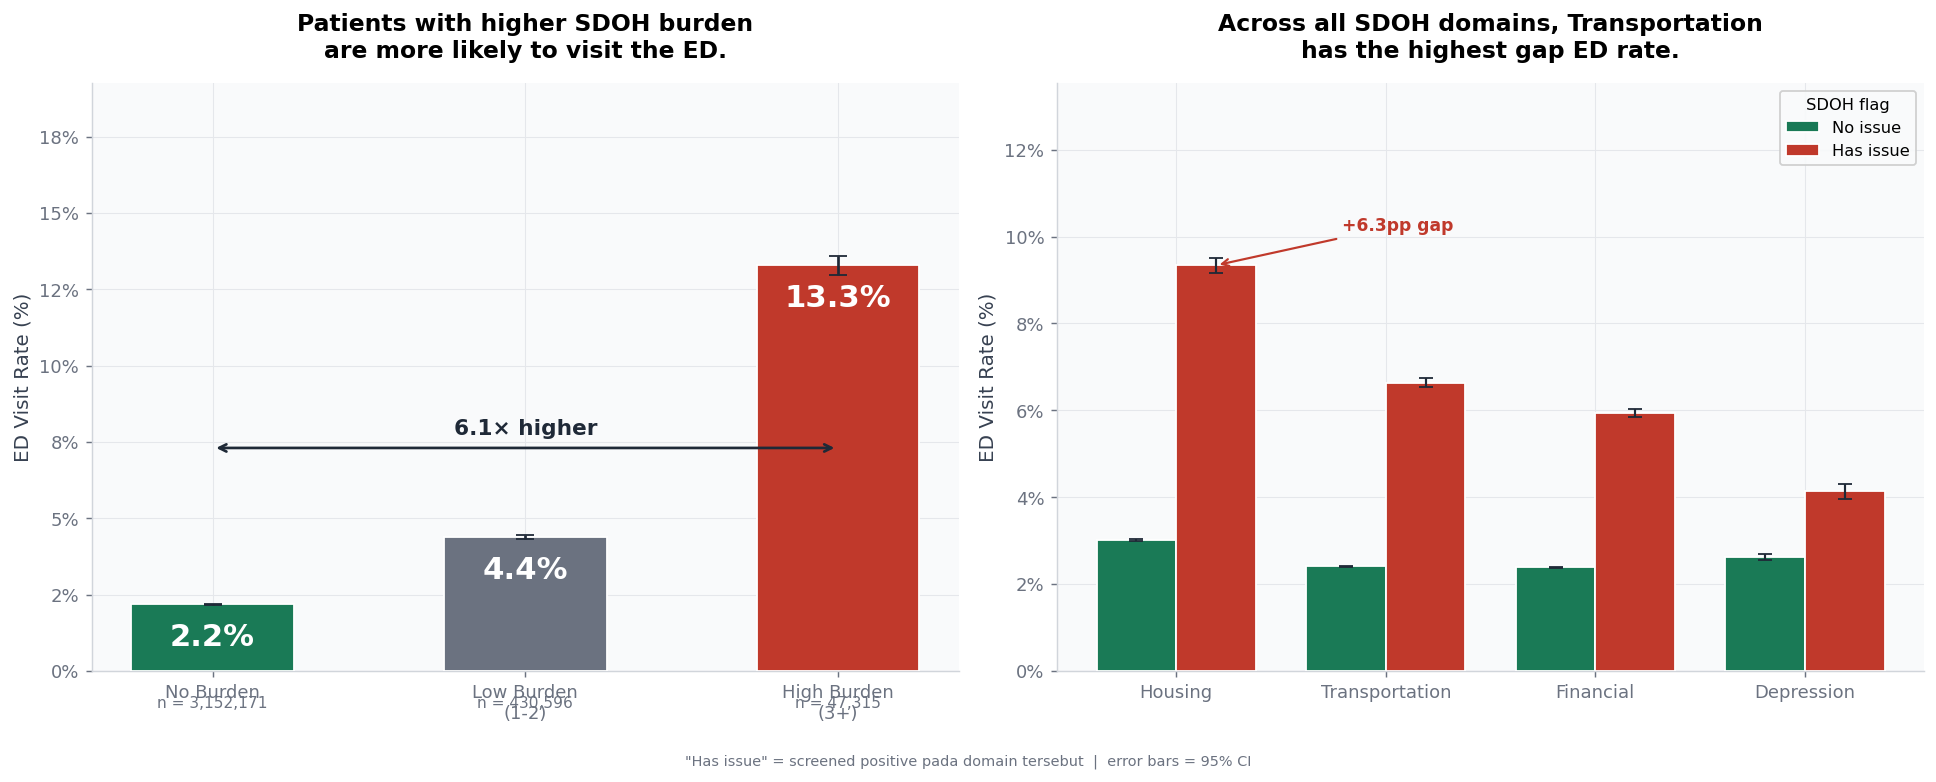

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot1_sdoh_burden_ed.png


In [13]:
def plot_sdoh_burden_ed(master_df, enc_full):
    import matplotlib.ticker as mticker
    import numpy as np

    TIERS = ['No Burden', 'Low Burden (1-2)', 'High Burden (3+)']
    TLABS = ['No Burden', 'Low Burden\n(1-2)', 'High Burden\n(3+)']

    # ── Data kiri: 3-tier ED rate ──────────────────────────────────────
    tier_ed = (
        master_df[master_df['burden_tier'].isin(TIERS)]
        .groupby('burden_tier')['IsEdVisit']
        .agg(['mean', 'count'])
        .reindex(TIERS)
        .reset_index()
    )
    tier_ed.columns = ['tier', 'rate', 'n']
    tier_ed['rate_pct'] = tier_ed['rate'] * 100
    tier_ed['ci95']     = (1.96 * np.sqrt(
        tier_ed['rate'] * (1 - tier_ed['rate']) / tier_ed['n']
    ) * 100)

    # ── Data kanan: per-domain grouped bar ────────────────────────────
    DOMAINS = {
        'score_housing'   : 'Housing',
        'score_transport' : 'Transportation',
        'score_financial' : 'Financial',
        'score_depression': 'Depression',
    }
    domain_rows = []
    for col, label in DOMAINS.items():
        if col not in master_df.columns:
            continue
        sub        = master_df[master_df[col].notna()].copy()
        has        = sub[sub[col] >= 1]['IsEdVisit']
        nohas      = sub[sub[col] == 0]['IsEdVisit']
        has_rate   = has.mean() * 100
        nohas_rate = nohas.mean() * 100
        has_ci     = 1.96 * has.sem() * 100
        nohas_ci   = 1.96 * nohas.sem() * 100
        domain_rows.append({
            'domain'   : label,
            'has_issue': has_rate,
            'no_issue' : nohas_rate,
            'gap'      : has_rate - nohas_rate,
            'has_ci'   : has_ci,
            'nohas_ci' : nohas_ci,
        })

    # Urutan fixed: Housing, Transportation, Financial, Depression
    order  = ['Housing', 'Transportation', 'Financial', 'Depression']
    dom_df = (pd.DataFrame(domain_rows)
              .set_index('domain')
              .reindex(order)
              .reset_index()
              .dropna(subset=['has_issue']))

    # ── Figure ────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor('white')

    # ═══ PANEL KIRI: 3-tier bar ═══════════════════════════════════════
    bars1 = ax1.bar(TLABS, tier_ed['rate_pct'],
                    color=TIER_COLORS, width=0.52,
                    edgecolor='white', zorder=3)
    ax1.errorbar(range(3), tier_ed['rate_pct'], yerr=tier_ed['ci95'],
                 fmt='none', color=C_DARK, capsize=5, lw=1.5, zorder=4)

    for bar, row in zip(bars1, tier_ed.itertuples()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() - 0.6,
                 f'{row.rate_pct:.1f}%',
                 ha='center', va='top',
                 fontsize=17, fontweight='bold', color='white')
        ax1.text(bar.get_x() + bar.get_width() / 2, -0.8,
                 f'n = {row.n:,}',
                 ha='center', va='top', fontsize=8.5, color=C_NEUTRAL)

    # Panah ratio
    if tier_ed['rate_pct'].iloc[0] > 0:
        ratio = tier_ed['rate_pct'].iloc[2] / tier_ed['rate_pct'].iloc[0]
        mid_y = tier_ed['rate_pct'].iloc[2] * 0.55
        ax1.annotate('', xy=(2, mid_y), xytext=(0, mid_y),
                     arrowprops=dict(arrowstyle='<->', color=C_DARK, lw=1.5))
        ax1.text(1, mid_y + 0.3, f'{ratio:.1f}× higher',
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold', color=C_DARK)

    ax1.set_ylabel('ED Visit Rate (%)', fontsize=11)
    ax1.set_ylim(0, tier_ed['rate_pct'].max() * 1.45)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax1.set_title(
        'Patients with higher SDOH burden\nare more likely to visit the ED.',
        fontsize=13, fontweight='bold', pad=14
    )

    # ═══ PANEL KANAN: grouped bar per domain ══════════════════════════
    x = np.arange(len(dom_df))
    w = 0.38

    bars_no  = ax2.bar(x - w / 2, dom_df['no_issue'], width=w,
                       color=C_SAFE, label='No issue',
                       edgecolor='white', zorder=3)
    bars_has = ax2.bar(x + w / 2, dom_df['has_issue'], width=w,
                       color=C_RISK, label='Has issue',
                       edgecolor='white', zorder=3)

    ax2.errorbar(x - w / 2, dom_df['no_issue'],  yerr=dom_df['nohas_ci'],
                 fmt='none', color=C_DARK, capsize=4, lw=1.2, zorder=4)
    ax2.errorbar(x + w / 2, dom_df['has_issue'], yerr=dom_df['has_ci'],
                 fmt='none', color=C_DARK, capsize=4, lw=1.2, zorder=4)

    # Annotasi gap terbesar
    max_gap_idx = dom_df['gap'].idxmax()
    max_row     = dom_df.loc[max_gap_idx]
    ax2.annotate(
        f'+{max_row["gap"]:.1f}pp gap',
        xy=(max_gap_idx + w / 2, max_row['has_issue']),
        xytext=(max_gap_idx + w / 2 + 0.6, max_row['has_issue'] + 0.8),
        fontsize=9.5, color=C_RISK, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=C_RISK, lw=1.2)
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(dom_df['domain'], fontsize=10)
    ax2.set_ylabel('ED Visit Rate (%)', fontsize=11)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax2.set_ylim(0, dom_df['has_issue'].max() * 1.45)
    ax2.set_title(
        'Across all SDOH domains, Transportation\nhas the highest gap ED rate.',
        fontsize=13, fontweight='bold', pad=14
    )
    ax2.legend(title='SDOH flag', fontsize=9, title_fontsize=9,
               loc='upper right', framealpha=0.9)

    fig.text(0.5, 0.01,
             '"Has issue" = screened positive pada domain tersebut  |  error bars = 95% CI',
             ha='center', fontsize=8, color=C_NEUTRAL)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    path = f'{OUTPUT_DIR}/plot1_sdoh_burden_ed.png'
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {path}')

plot_sdoh_burden_ed(master_df, enc_full)

---
## 13 · Plot 2 — ED Cycling Rate per Burden Tier
> **Story:** Once high-burden patients enter the ED, they're almost 2.4× more likely to return via ED again — they're trapped in the cycle.


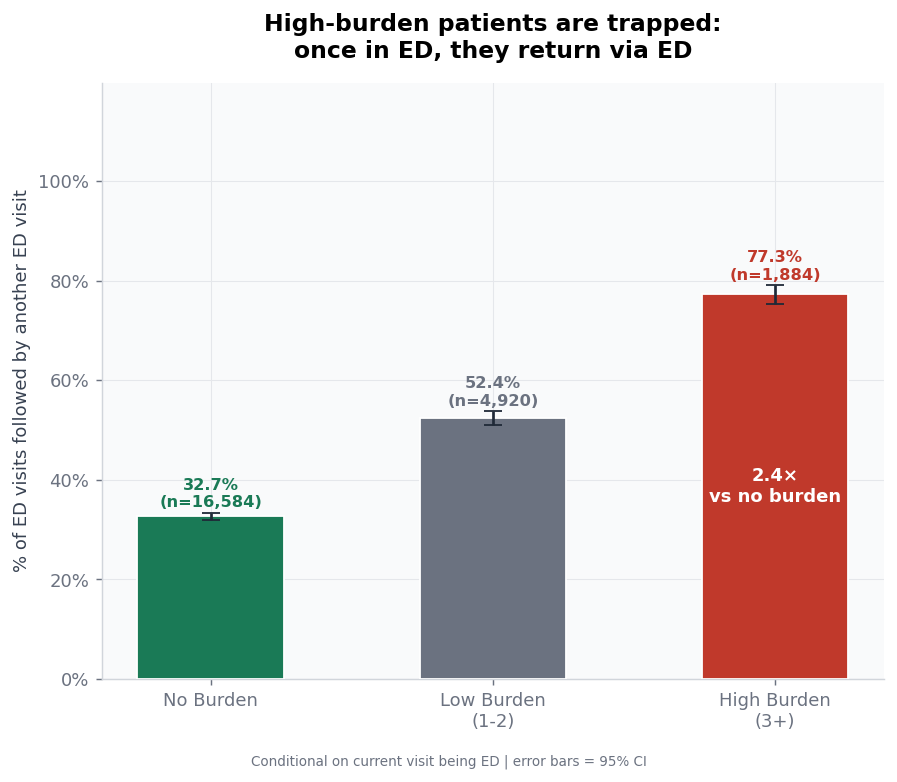

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot2_ed_cycling.png
   No Burden                : 32.70%  (n=16,584)
   Low Burden (1-2)         : 52.44%  (n=4,920)
   High Burden (3+)         : 77.28%  (n=1,884)


In [14]:
def plot_ed_cycling(enc_full):
    TIERS = ['No Burden','Low Burden (1-2)','High Burden (3+)']
    TLABS = ['No Burden','Low Burden\n(1-2)','High Burden\n(3+)']
    ed_only = enc_full[(enc_full['IsEdVisit']==1) & (enc_full['Next_Is_ED'].notna()) &
                       (enc_full['burden_tier'].isin(TIERS))].copy()
    rates, ns, cis = [], [], []
    for tier in TIERS:
        sub = ed_only[ed_only['burden_tier']==tier]['Next_Is_ED']
        rates.append(sub.mean()*100); ns.append(len(sub)); cis.append(1.96*sub.sem()*100)

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(TLABS, rates, color=TIER_COLORS, width=0.52, edgecolor='white', zorder=3)
    ax.errorbar(range(3), rates, yerr=cis, fmt='none', color=C_DARK, capsize=5, lw=1.5, zorder=4)
    for bar, rate, n, ci in zip(bars, rates, ns, cis):
        ax.text(bar.get_x()+bar.get_width()/2, rate+ci+0.5,
                f'{rate:.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=bar.get_facecolor())
    if rates[0] > 0:
        ratio = rates[2] / rates[0]
        ax.text(2, rates[2]/2, f'{ratio:.1f}×\nvs no burden',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.set_ylabel('% of ED visits followed by another ED visit', fontsize=10)
    ax.set_ylim(0, max(rates)*1.55)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title('High-burden patients are trapped:\nonce in ED, they return via ED',
                 fontsize=13, fontweight='bold', pad=14)
    fig.text(0.5, 0.01, 'Conditional on current visit being ED | error bars = 95% CI',
             ha='center', fontsize=7.5, color=C_NEUTRAL)
    plt.tight_layout(rect=[0,0.03,1,1])
    path = f'{OUTPUT_DIR}/plot2_ed_cycling.png'
    plt.savefig(path); plt.show()
    print(f'✅ Saved: {path}')
    for tier, rate, n in zip(TIERS, rates, ns):
        print(f'   {tier:<25}: {rate:.2f}%  (n={n:,})')

plot_ed_cycling(enc_full)


---
## 14 · Plot 3 — SDOH Score Correlation vs ED Rate
> **Story:** The higher a county's average SDOH composite score, the higher its ED visit rate.  
> Breakdown by individual domain shows *which* social needs drive ED utilization most strongly — pointing to where hospital outreach should focus.


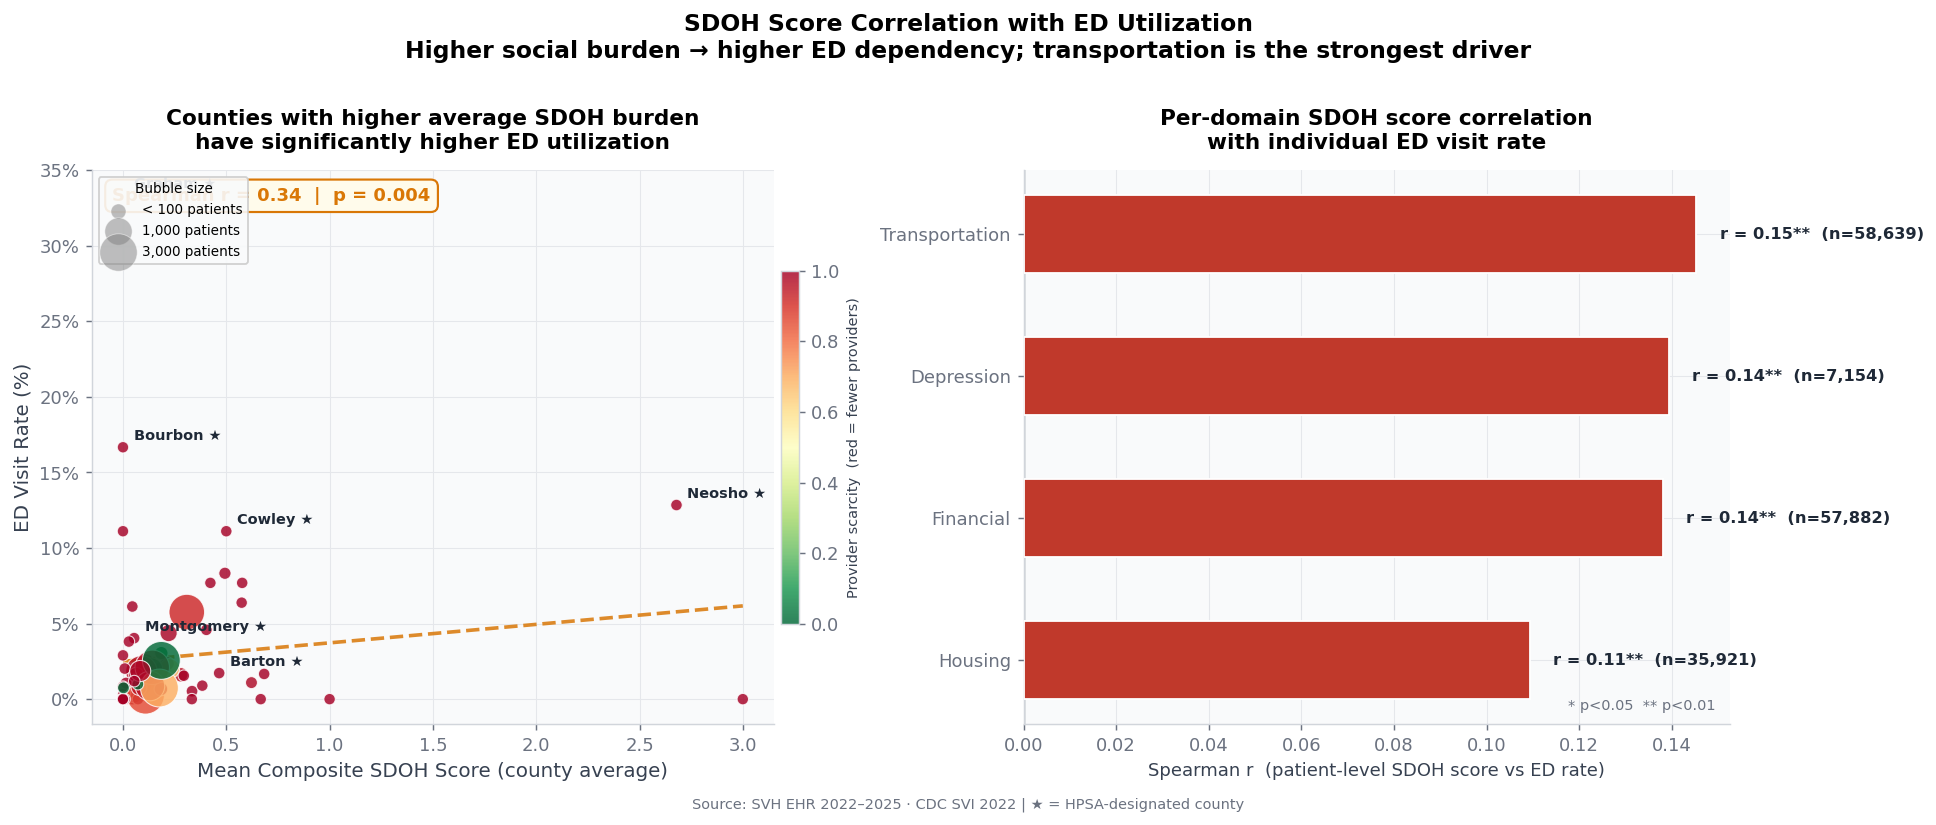

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot3_sdoh_correlation.png

Domain correlations with ED rate (patient-level Spearman r):
   Transportation      : r = +0.145  [**]  n = 58,639
   Depression          : r = +0.139  [**]  n = 7,154
   Financial           : r = +0.138  [**]  n = 57,882
   Housing             : r = +0.109  [**]  n = 35,921


In [15]:
def plot_sdoh_correlation(master_df, sdoh_county):
    """
    Two-panel correlation figure:
    Left  — county-level scatter: composite SDOH score vs ED rate (Spearman + regression)
    Right — bar chart: Spearman r per individual SDOH domain vs ED rate (patient-level)
    """
    sc = sdoh_county.dropna(subset=['sdoh_mean','ed_rate_pct','RPL_THEMES']).copy()
    DOMAIN_MAP = {
        'score_transport' : 'Transportation',
        'score_financial' : 'Financial',
        'score_food'      : 'Food',
        'score_housing'   : 'Housing',
        'score_depression': 'Depression',
    }

    # Per-domain Spearman r vs ED rate (patient-level)
    domain_corr = []
    pt_ed = master_df.groupby('PatientDurableKey')['IsEdVisit'].mean().reset_index()
    pt_ed.columns = ['PatientDurableKey','ed_rate']
    for col, label in DOMAIN_MAP.items():
        if col not in master_df.columns:
            continue
        tmp = master_df[['PatientDurableKey', col]].dropna().drop_duplicates('PatientDurableKey')
        tmp = tmp.merge(pt_ed, on='PatientDurableKey', how='inner')
        if len(tmp) < 30:
            continue
        r, p = stats.spearmanr(tmp[col], tmp['ed_rate'])
        domain_corr.append({'domain': label, 'r': r, 'p': p,
                            'n': len(tmp), 'sig': p < 0.05})
    dom_df = pd.DataFrame(domain_corr).sort_values('r', ascending=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ── Left: county scatter ───────────────────────────────────────────
    prov_norm = 1 - (sc['n_providers'].clip(upper=sc['n_providers'].quantile(0.95))
                     / sc['n_providers'].clip(upper=sc['n_providers'].quantile(0.95)).max())
    sizes     = sc['n_patients'].clip(upper=3000) / 3000 * 400 + 40

    scat = ax1.scatter(sc['sdoh_mean'], sc['ed_rate_pct'],
                       c=prov_norm, cmap='RdYlGn_r',
                       s=sizes, alpha=0.82, edgecolors='white', linewidths=0.6,
                       zorder=3, vmin=0, vmax=1)
    cb = plt.colorbar(scat, ax=ax1, fraction=0.025, pad=0.01, shrink=0.7)
    cb.set_label('Provider scarcity  (red = fewer providers)', fontsize=8)

    # Regression line + stats
    valid_r = sc[sc['sdoh_mean'].notna() & sc['ed_rate_pct'].notna()]
    if len(valid_r) >= 4:
        z  = np.polyfit(valid_r['sdoh_mean'], valid_r['ed_rate_pct'], 1)
        xs = np.linspace(valid_r['sdoh_mean'].min(), valid_r['sdoh_mean'].max(), 100)
        ax1.plot(xs, np.poly1d(z)(xs), color=C_WARN, linestyle='--', linewidth=2, alpha=0.85, zorder=2)
        r_val, p_val = stats.spearmanr(valid_r['sdoh_mean'], valid_r['ed_rate_pct'])
        sig_lbl = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
        ax1.text(0.03, 0.97, f'Spearman r = {r_val:.2f}  |  {sig_lbl}',
                 transform=ax1.transAxes, ha='left', va='top', fontsize=10, fontweight='bold',
                 color=C_WARN, bbox=dict(boxstyle='round,pad=0.4', fc='#FFFBEB', ec=C_WARN, lw=1.2))

    # Label top counties by need_score
    for _, row in sc.nlargest(6, 'need_score').iterrows():
        hpsa_tag = ' ★' if row.get('is_hpsa', 0) == 1 else ''
        ax1.annotate(f"{row.get('county_label','')}{hpsa_tag}",
                     xy=(row['sdoh_mean'], row['ed_rate_pct']),
                     xytext=(6, 4), textcoords='offset points',
                     fontsize=8, color=C_DARK, fontweight='bold')

    # Bubble size legend
    for bsize, blbl in [(40+30,'< 100 patients'), (200+30,'1,000 patients'), (400+30,'3,000 patients')]:
        ax1.scatter([],[], s=bsize, c='gray', alpha=0.5, edgecolors='white', lw=0.5, label=blbl)
    ax1.legend(fontsize=7.5, loc='upper left', title='Bubble size', title_fontsize=7.5, framealpha=0.9)

    ax1.set_xlabel('Mean Composite SDOH Score (county average)', fontsize=11)
    ax1.set_ylabel('ED Visit Rate (%)', fontsize=11)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax1.set_title('Counties with higher average SDOH burden\nhave significantly higher ED utilization',
                  fontsize=12, fontweight='bold', pad=12)

    # ── Right: per-domain bar ──────────────────────────────────────────
    if len(dom_df) > 0:
        bar_colors = [C_RISK if r > 0 else C_SAFE for r in dom_df['r']]
        bars2 = ax2.barh(dom_df['domain'], dom_df['r'],
                         color=bar_colors, edgecolor='white', height=0.55, zorder=3)
        for bar, row in zip(bars2, dom_df.itertuples()):
            sig_marker = '**' if row.p < 0.01 else ('*' if row.p < 0.05 else '')
            x_off = 0.005 if row.r >= 0 else -0.005
            ha    = 'left' if row.r >= 0 else 'right'
            ax2.text(row.r + x_off, bar.get_y()+bar.get_height()/2,
                     f'r = {row.r:.2f}{sig_marker}  (n={row.n:,})',
                     va='center', ha=ha, fontsize=9, color=C_DARK, fontweight='bold')
        ax2.axvline(0, color=C_DARK, linewidth=0.8, alpha=0.5)
        ax2.set_xlabel('Spearman r  (patient-level SDOH score vs ED rate)', fontsize=10)
        ax2.set_title('Per-domain SDOH score correlation\nwith individual ED visit rate',
                      fontsize=12, fontweight='bold', pad=12)
        ax2.text(0.98, 0.02, '* p<0.05  ** p<0.01',
                 transform=ax2.transAxes, ha='right', va='bottom', fontsize=8, color=C_NEUTRAL)
    else:
        ax2.text(0.5, 0.5, 'Insufficient domain data\nfor correlation analysis',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=11, color=C_NEUTRAL)

    fig.suptitle(
        'SDOH Score Correlation with ED Utilization\n'
        'Higher social burden → higher ED dependency; transportation is the strongest driver',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.text(0.5, -0.01, 'Source: SVH EHR 2022–2025 · CDC SVI 2022 | ★ = HPSA-designated county',
             ha='center', fontsize=8, color=C_NEUTRAL)

    plt.tight_layout()
    path = f'{OUTPUT_DIR}/plot3_sdoh_correlation.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'✅ Saved: {path}')
    if len(dom_df) > 0:
        print('\nDomain correlations with ED rate (patient-level Spearman r):')
        for _, row in dom_df.sort_values('r', ascending=False).iterrows():
            sig = '**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'ns')
            print(f'   {row["domain"]:<20}: r = {row["r"]:+.3f}  [{sig}]  n = {row["n"]:,}')

plot_sdoh_correlation(master_df, sdoh_county)


---
## 15 · Plot 4 — HPSA Provider Shortage Map + Transport × HPSA Interaction
> **Story:** HPSA-designated counties (officially undersupplied) combined with transport barriers create the highest ED rates.


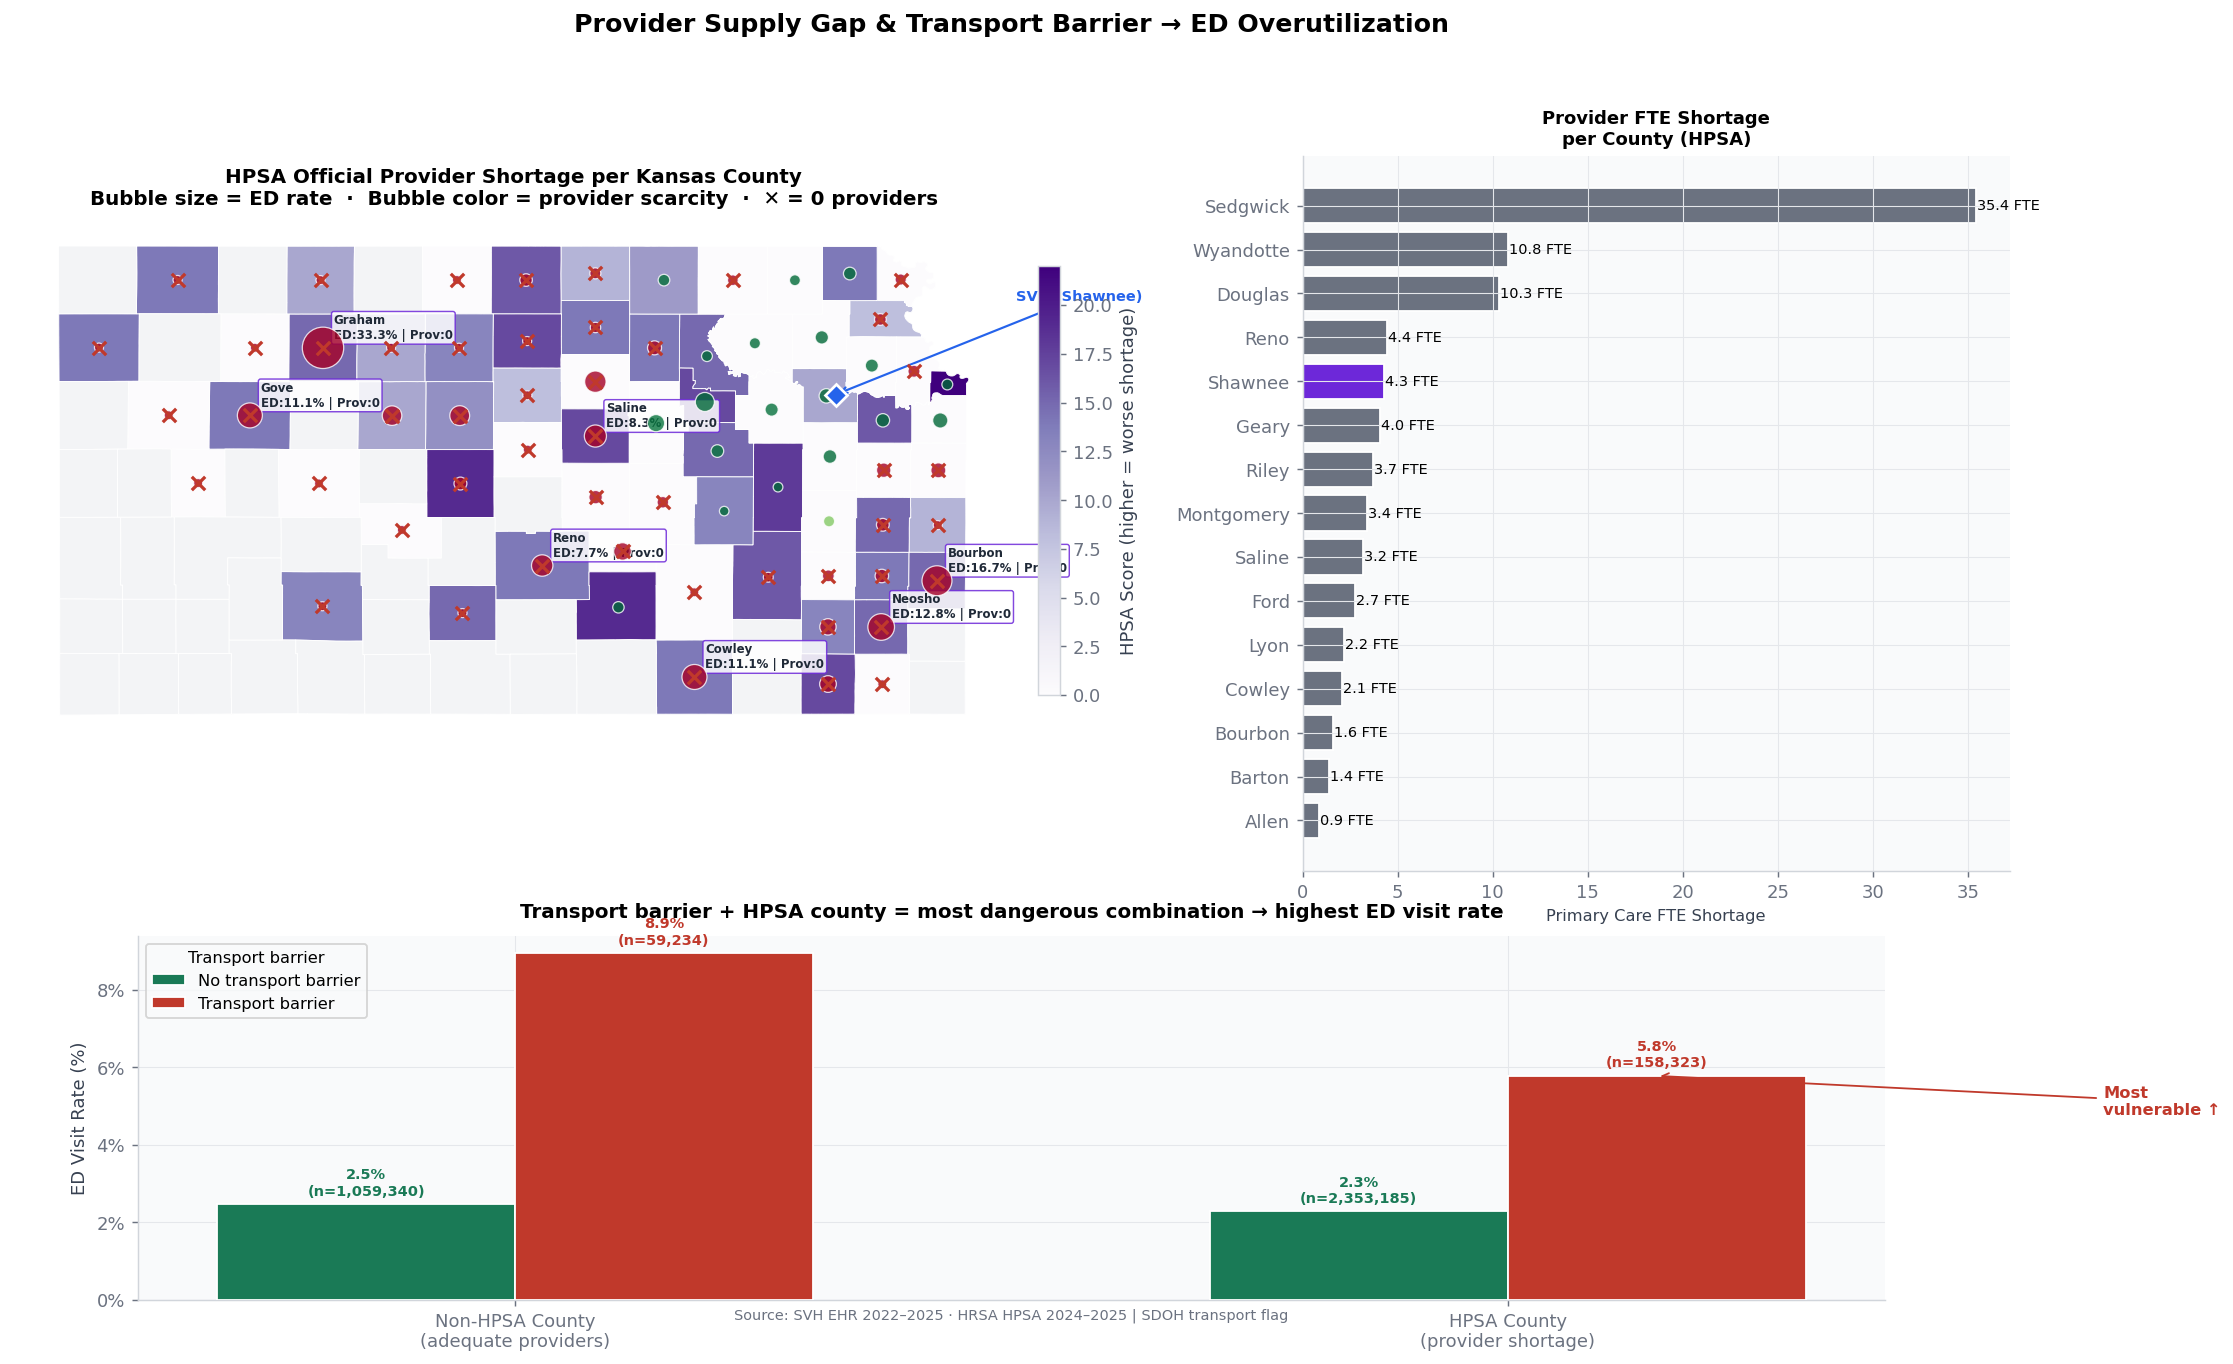

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot4_hpsa_transport.png


In [16]:
def plot_hpsa_provider_map(sdoh_county):
    sc = sdoh_county.dropna(subset=['RPL_THEMES']).copy()
    sc['hpsa_score_plot'] = sc['hpsa_score'].fillna(0)

    # ── Bottom bar: transport barrier × HPSA county interaction ───────
    # Uses master_df which is in scope
    groups = master_df.assign(
        is_hpsa_county = lambda d: (d['is_hpsa_designated'] == 1).astype(int)
    ).groupby(['is_hpsa_county','Transport_Issue'])['IsEdVisit'].agg(['mean','count']).reset_index()
    groups.columns = ['is_hpsa','transport','rate','n']
    groups['rate_pct'] = groups['rate'] * 100
    groups['label'] = groups.apply(
        lambda r: ('HPSA County\n(provider shortage)' if r['is_hpsa'] == 1
                   else 'Non-HPSA County\n(adequate providers)'), axis=1)

    try:
        import geopandas as gpd
        CACHE = f'{BASE}/ExternalData/ks_counties.gpkg'
        if os.path.exists(CACHE):
            ks_geo = gpd.read_file(CACHE)
        else:
            all_c  = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip')
            ks_geo = all_c[all_c['STATEFP'] == '20'].copy()
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
            ks_geo.to_file(CACHE, driver='GPKG')
        if 'FIPS' not in ks_geo.columns:
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
        ks_geo = ks_geo.merge(sc, left_on='FIPS', right_on='county_fips', how='left')

        fig = plt.figure(figsize=(16, 10))
        ax_map = fig.add_axes([0.02, 0.35, 0.58, 0.60])
        ax_bar = fig.add_axes([0.64, 0.35, 0.34, 0.55])
        ax_bot = fig.add_axes([0.08, 0.02, 0.84, 0.28])

        # ── Map: HPSA score choropleth ─────────────────────────────────
        ax_map.set_facecolor('#EEF2F7')
        ks_geo.plot(column='hpsa_score_plot', ax=ax_map, cmap='Purples',
                    linewidth=0.5, edgecolor='white',
                    legend=True,
                    legend_kwds={'label':'HPSA Score (higher = worse shortage)',
                                 'orientation':'vertical','shrink':0.55,'pad':0.02},
                    missing_kwds={'color':'#F3F4F6'}, vmin=0)

        # Bubble overlay: ED rate, color = provider scarcity
        centroids = ks_geo.copy()
        centroids['cx'] = centroids.geometry.centroid.x
        centroids['cy'] = centroids.geometry.centroid.y
        valid_b = centroids[centroids['ed_rate_pct'].notna() & (centroids['n_patients'] > 0)].copy()
        prov_s  = 1 / valid_b['n_providers'].clip(lower=1)
        prov_n  = (prov_s - prov_s.min()) / (prov_s.max() - prov_s.min() + 1e-9)
        bsizes  = (valid_b['ed_rate_pct'] / valid_b['ed_rate_pct'].max()) * 500 + 25
        ax_map.scatter(valid_b['cx'], valid_b['cy'], s=bsizes, c=prov_n,
                       cmap='RdYlGn_r', alpha=0.80, edgecolors='white', linewidths=0.7,
                       zorder=4, vmin=0, vmax=1)
        zero_p = valid_b[valid_b['n_providers'] == 0]
        if len(zero_p):
            ax_map.scatter(zero_p['cx'], zero_p['cy'], s=55, marker='x',
                           c='#C0392B', linewidths=1.8, zorder=5)
        # Labels for at-risk counties
        at_risk = valid_b[(valid_b['ed_rate_pct'] > valid_b['ed_rate_pct'].quantile(0.7)) &
                          (valid_b['hpsa_score_plot'] > 0)].nlargest(7, 'ed_rate_pct')
        for _, row in at_risk.iterrows():
            ax_map.annotate(
                f"{row.get('county_label','?')}\nED:{row['ed_rate_pct']:.1f}% | Prov:{int(row['n_providers'])}",
                xy=(row['cx'], row['cy']), xytext=(6,5), textcoords='offset points',
                fontsize=6.5, fontweight='bold', color='#1F2937',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#6D28D9', alpha=0.85, lw=0.8))
        ax_map.plot(-95.6752, 39.0473, 'D', ms=9, color=C_ACCENT, mec='white', mew=1.5, zorder=6)
        ax_map.annotate('SVH (Shawnee)', xy=(-95.68,39.05), xytext=(-94.2,39.65),
                        fontsize=8, color=C_ACCENT, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.2))
        ax_map.set_axis_off()
        ax_map.set_title(
            'HPSA Official Provider Shortage per Kansas County\n'
            'Bubble size = ED rate  ·  Bubble color = provider scarcity  ·  ✕ = 0 providers',
            fontsize=11, fontweight='bold', pad=10)

        # ── Bar: FTE shortage top counties ────────────────────────────
        fte_data = sc[sc['hpsa_fte'] > 0].nlargest(15,'hpsa_fte').sort_values('hpsa_fte')
        bar_cols = [C_HPSA if lbl.lower()=='shawnee' else C_NEUTRAL
                    for lbl in fte_data['county_label']]
        ax_bar.barh(fte_data['county_label'], fte_data['hpsa_fte'],
                    color=bar_cols, edgecolor='white')
        for bar, val in zip(ax_bar.patches, fte_data['hpsa_fte']):
            if val > 0:
                ax_bar.text(val+0.05, bar.get_y()+bar.get_height()/2,
                            f'{val:.1f} FTE', va='center', fontsize=8)
        ax_bar.set_xlabel('Primary Care FTE Shortage', fontsize=9)
        ax_bar.set_title('Provider FTE Shortage\nper County (HPSA)', fontsize=10, fontweight='bold')

        # ── Bottom: transport × HPSA interaction ──────────────────────
        hpsa_labs   = ['Non-HPSA County\n(adequate providers)', 'HPSA County\n(provider shortage)']
        bar_width   = 0.3
        x_pos       = [0, 1]
        for i, hpsa_flag in enumerate([0, 1]):
            for j, trans_flag in enumerate([0, 1]):
                row = groups[(groups['is_hpsa']==hpsa_flag) & (groups['transport']==trans_flag)]
                if row.empty: continue
                rate = row['rate_pct'].values[0]
                n    = row['n'].values[0]
                color = C_RISK if trans_flag == 1 else C_SAFE
                xpos  = i - bar_width/2 + j * bar_width
                bar   = ax_bot.bar(xpos, rate, width=bar_width, color=color,
                                   edgecolor='white', zorder=3,
                                   label=('Transport barrier' if trans_flag==1 else 'No transport barrier')
                                         if i==0 else '_')
                ax_bot.text(xpos, rate + 0.15, f'{rate:.1f}%\n(n={n:,})',
                            ha='center', va='bottom', fontsize=8, fontweight='bold',
                            color=color)
        ax_bot.set_xticks([0, 1]); ax_bot.set_xticklabels(hpsa_labs, fontsize=10)
        ax_bot.set_ylabel('ED Visit Rate (%)', fontsize=10)
        ax_bot.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        ax_bot.set_title(
            'Transport barrier + HPSA county = most dangerous combination → highest ED visit rate',
            fontsize=11, fontweight='bold', pad=10)
        ax_bot.legend(title='Transport barrier', fontsize=9, title_fontsize=9, loc='upper left')

        # Mark the most vulnerable bar
        hpsa1_trans1 = groups[(groups['is_hpsa']==1) & (groups['transport']==1)]
        if not hpsa1_trans1.empty:
            ax_bot.annotate('Most\nvulnerable ↑',
                            xy=(1 + bar_width/2, hpsa1_trans1['rate_pct'].values[0]),
                            xytext=(1.6, hpsa1_trans1['rate_pct'].values[0] - 1),
                            fontsize=9, color=C_RISK, fontweight='bold',
                            arrowprops=dict(arrowstyle='->', color=C_RISK, lw=1))

        fig.text(0.5, 0.005, 'Source: SVH EHR 2022–2025 · HRSA HPSA 2024–2025 | SDOH transport flag',
                 ha='center', fontsize=8, color=C_NEUTRAL)

    except Exception as e:
        print(f'⚠️  Choropleth failed ({e}) — bar-only fallback')
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fte_data = sc[sc['hpsa_fte'] > 0].nlargest(15,'hpsa_fte').sort_values('hpsa_fte')
        axes[0].barh(fte_data['county_label'], fte_data['hpsa_fte'],
                     color=C_HPSA, alpha=0.85, edgecolor='white')
        axes[0].set_xlabel('Primary Care FTE Shortage')
        axes[0].set_title('Provider FTE Shortage per County (HPSA)', fontweight='bold')
        hpsa_labs = ['Non-HPSA County', 'HPSA County']
        for i, hpsa_flag in enumerate([0,1]):
            for j, trans_flag in enumerate([0,1]):
                row = groups[(groups['is_hpsa']==hpsa_flag) & (groups['transport']==trans_flag)]
                if row.empty: continue
                axes[1].bar(i - 0.15 + j*0.3, row['rate_pct'].values[0], width=0.3,
                            color=C_RISK if trans_flag==1 else C_SAFE, edgecolor='white')
        axes[1].set_xticks([0,1]); axes[1].set_xticklabels(hpsa_labs)
        axes[1].set_title('Transport barrier + HPSA = highest ED rate', fontweight='bold')

    plt.suptitle('Provider Supply Gap & Transport Barrier → ED Overutilization',
                 fontsize=14, fontweight='bold', y=1.01)
    path = f'{OUTPUT_DIR}/plot4_hpsa_transport.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'✅ Saved: {path}')

plot_hpsa_provider_map(sdoh_county)


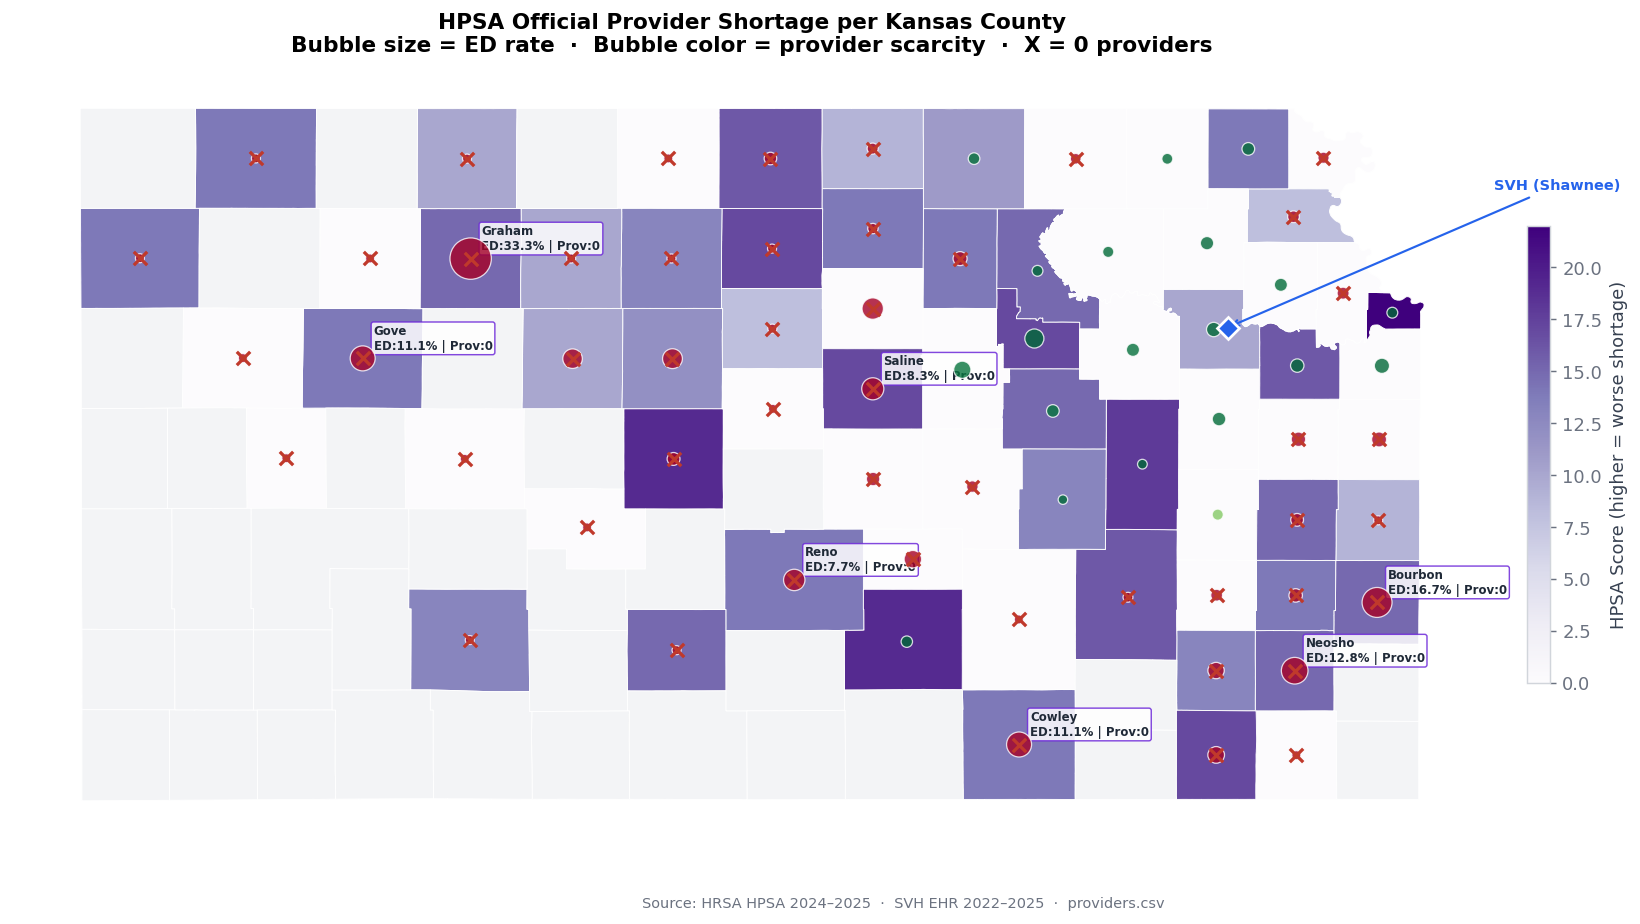

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot4a_hpsa_map.png


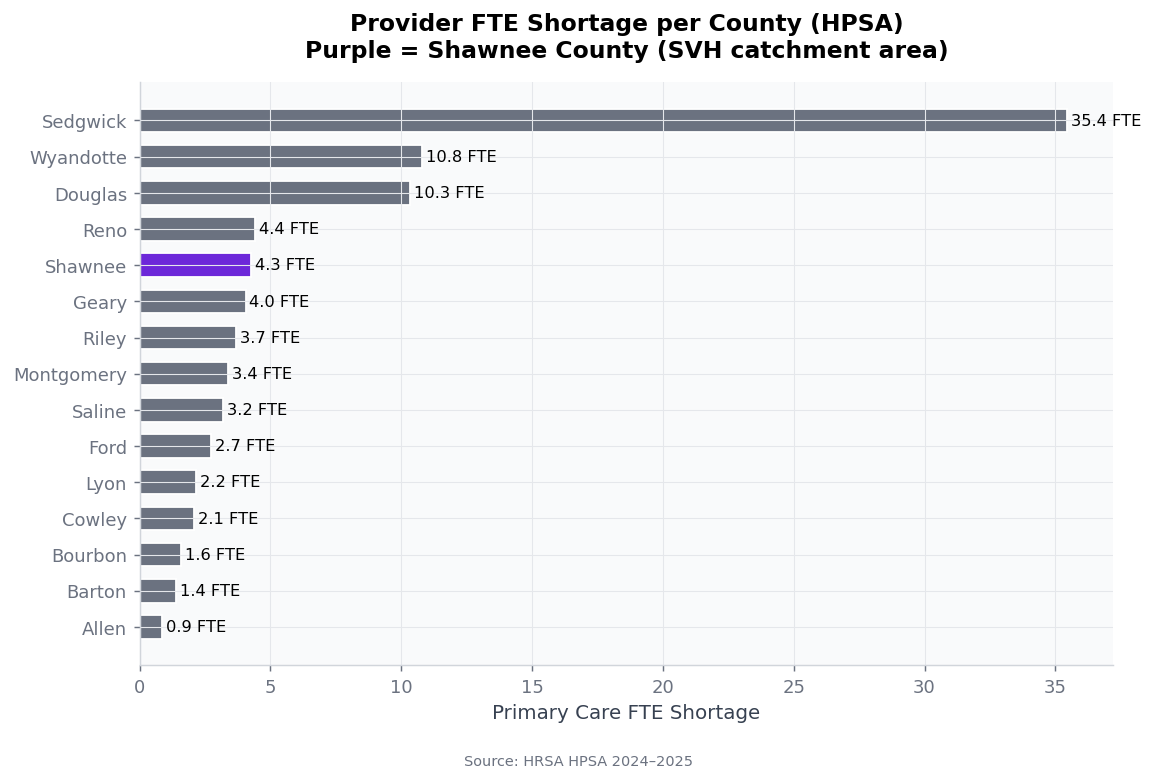

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot4b_fte_bar.png


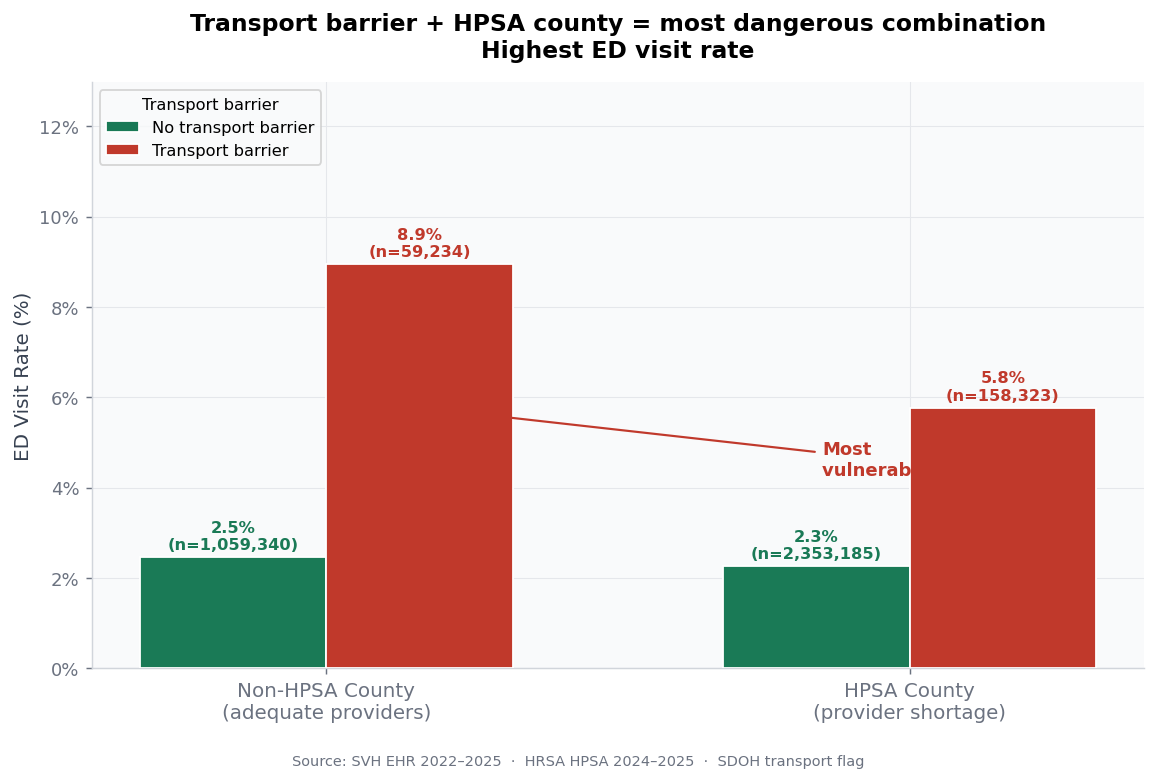

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot4c_transport_hpsa.png


In [21]:
# ══════════════════════════════════════════════════════════════════════
# PLOT 4a — HPSA Choropleth Map + ED Bubble Overlay
# ══════════════════════════════════════════════════════════════════════

def plot_hpsa_map(sdoh_county):
    sc = sdoh_county.dropna(subset=['RPL_THEMES']).copy()
    sc['hpsa_score_plot'] = sc['hpsa_score'].fillna(0)

    try:
        import geopandas as gpd
        CACHE = f'{BASE}/ExternalData/ks_counties.gpkg'
        if os.path.exists(CACHE):
            ks_geo = gpd.read_file(CACHE)
        else:
            all_c  = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip')
            ks_geo = all_c[all_c['STATEFP'] == '20'].copy()
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
            ks_geo.to_file(CACHE, driver='GPKG')
        if 'FIPS' not in ks_geo.columns:
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
        ks_geo = ks_geo.merge(sc, left_on='FIPS', right_on='county_fips', how='left')

        fig, ax_map = plt.subplots(figsize=(14, 7))
        fig.patch.set_facecolor('white')
        ax_map.set_facecolor('#EEF2F7')

        ks_geo.plot(column='hpsa_score_plot', ax=ax_map, cmap='Purples',
                    linewidth=0.5, edgecolor='white',
                    legend=True,
                    legend_kwds={'label':'HPSA Score (higher = worse shortage)',
                                 'orientation':'vertical','shrink':0.55,'pad':0.02},
                    missing_kwds={'color':'#F3F4F6'}, vmin=0)

        centroids = ks_geo.copy()
        centroids['cx'] = centroids.geometry.centroid.x
        centroids['cy'] = centroids.geometry.centroid.y
        valid_b = centroids[centroids['ed_rate_pct'].notna() & (centroids['n_patients'] > 0)].copy()
        prov_s  = 1 / valid_b['n_providers'].clip(lower=1)
        prov_n  = (prov_s - prov_s.min()) / (prov_s.max() - prov_s.min() + 1e-9)
        bsizes  = (valid_b['ed_rate_pct'] / valid_b['ed_rate_pct'].max()) * 500 + 25
        ax_map.scatter(valid_b['cx'], valid_b['cy'], s=bsizes, c=prov_n,
                       cmap='RdYlGn_r', alpha=0.80, edgecolors='white', linewidths=0.7,
                       zorder=4, vmin=0, vmax=1)

        zero_p = valid_b[valid_b['n_providers'] == 0]
        if len(zero_p):
            ax_map.scatter(zero_p['cx'], zero_p['cy'], s=55, marker='x',
                           c='#C0392B', linewidths=1.8, zorder=5)

        at_risk = valid_b[(valid_b['ed_rate_pct'] > valid_b['ed_rate_pct'].quantile(0.7)) &
                          (valid_b['hpsa_score_plot'] > 0)].nlargest(7, 'ed_rate_pct')
        for _, row in at_risk.iterrows():
            ax_map.annotate(
                f"{row.get('county_label','?')}\nED:{row['ed_rate_pct']:.1f}% | Prov:{int(row['n_providers'])}",
                xy=(row['cx'], row['cy']), xytext=(6, 5), textcoords='offset points',
                fontsize=6.5, fontweight='bold', color='#1F2937',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#6D28D9', alpha=0.85, lw=0.8))

        ax_map.plot(-95.6752, 39.0473, 'D', ms=9, color=C_ACCENT, mec='white', mew=1.5, zorder=6)
        ax_map.annotate('SVH (Shawnee)', xy=(-95.68, 39.05), xytext=(-94.2, 39.65),
                        fontsize=8, color=C_ACCENT, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.2))
        ax_map.set_axis_off()
        ax_map.set_title(
            'HPSA Official Provider Shortage per Kansas County\n'
            'Bubble size = ED rate  ·  Bubble color = provider scarcity  ·  X = 0 providers',
            fontsize=12, fontweight='bold', pad=12)

    except Exception as e:
        print(f'⚠️  Choropleth failed ({e}) — skipping map')
        return

    fig.text(0.5, 0.01, 'Source: HRSA HPSA 2024–2025  ·  SVH EHR 2022–2025  ·  providers.csv',
             ha='center', fontsize=8, color=C_NEUTRAL)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    path = f'{OUTPUT_DIR}/plot4a_hpsa_map.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'✅ Saved: {path}')

plot_hpsa_map(sdoh_county)


# ══════════════════════════════════════════════════════════════════════
# PLOT 4b — Provider FTE Shortage Bar Chart
# ══════════════════════════════════════════════════════════════════════

def plot_hpsa_fte_bar(sdoh_county):
    sc = sdoh_county.dropna(subset=['RPL_THEMES']).copy()
    fte_data = sc[sc['hpsa_fte'] > 0].nlargest(15, 'hpsa_fte').sort_values('hpsa_fte')

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor('white')

    bar_cols = [C_HPSA if lbl.lower() == 'shawnee' else C_NEUTRAL
                for lbl in fte_data['county_label']]
    bars = ax.barh(fte_data['county_label'], fte_data['hpsa_fte'],
                   color=bar_cols, edgecolor='white', height=0.65)

    for bar, val in zip(bars, fte_data['hpsa_fte']):
        if val > 0:
            ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f} FTE', va='center', fontsize=9)

    ax.set_xlabel('Primary Care FTE Shortage', fontsize=11)
    ax.set_title('Provider FTE Shortage per County (HPSA)\n'
                 'Purple = Shawnee County (SVH catchment area)',
                 fontsize=13, fontweight='bold', pad=14)
    fig.text(0.5, 0.01, 'Source: HRSA HPSA 2024–2025',
             ha='center', fontsize=8, color=C_NEUTRAL)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    path = f'{OUTPUT_DIR}/plot4b_fte_bar.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'✅ Saved: {path}')

plot_hpsa_fte_bar(sdoh_county)


# ══════════════════════════════════════════════════════════════════════
# PLOT 4c — Transport Barrier × HPSA County Interaction
# ══════════════════════════════════════════════════════════════════════

def plot_transport_hpsa_interaction(master_df):
    groups = master_df.assign(
        is_hpsa_county=lambda d: (d['is_hpsa_designated'] == 1).astype(int)
    ).groupby(['is_hpsa_county', 'Transport_Issue'])['IsEdVisit'].agg(['mean', 'count']).reset_index()
    groups.columns = ['is_hpsa', 'transport', 'rate', 'n']
    groups['rate_pct'] = groups['rate'] * 100

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor('white')

    hpsa_labs = ['Non-HPSA County\n(adequate providers)', 'HPSA County\n(provider shortage)']
    bar_width  = 0.32

    for i, hpsa_flag in enumerate([0, 1]):
        for j, trans_flag in enumerate([0, 1]):
            row = groups[(groups['is_hpsa'] == hpsa_flag) & (groups['transport'] == trans_flag)]
            if row.empty:
                continue
            rate  = row['rate_pct'].values[0]
            n     = row['n'].values[0]
            color = C_RISK if trans_flag == 1 else C_SAFE
            xpos  = i - bar_width / 2 + j * bar_width
            ax.bar(xpos, rate, width=bar_width, color=color, edgecolor='white', zorder=3,
                   label=('Transport barrier' if trans_flag == 1 else 'No transport barrier')
                         if i == 0 else '_')
            ax.text(xpos, rate + 0.1, f'{rate:.1f}%\n(n={n:,})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

    hpsa1_t1 = groups[(groups['is_hpsa'] == 1) & (groups['transport'] == 1)]
    if not hpsa1_t1.empty:
        ax.annotate('Most\nvulnerable ↑',
                    xy=(bar_width / 2, hpsa1_t1['rate_pct'].values[0]),
                    xytext=(0.85, hpsa1_t1['rate_pct'].values[0] - 1.5),
                    fontsize=10, color=C_RISK, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=C_RISK, lw=1.2))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(hpsa_labs, fontsize=11)
    ax.set_ylabel('ED Visit Rate (%)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_ylim(0, groups['rate_pct'].max() * 1.45)
    ax.set_title('Transport barrier + HPSA county = most dangerous combination\n'
                 'Highest ED visit rate',
                 fontsize=13, fontweight='bold', pad=14)
    ax.legend(title='Transport barrier', fontsize=9, title_fontsize=9, loc='upper left')

    fig.text(0.5, 0.01, 'Source: SVH EHR 2022–2025  ·  HRSA HPSA 2024–2025  ·  SDOH transport flag',
             ha='center', fontsize=8, color=C_NEUTRAL)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    path = f'{OUTPUT_DIR}/plot4c_transport_hpsa.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'✅ Saved: {path}')

plot_transport_hpsa_interaction(master_df)

---
## 15b · Plot 4b — Social Vulnerability & ED Utilization Map
> **Story:** County-level SVI choropleth with ED rate bubbles and SDOH burden overlay.


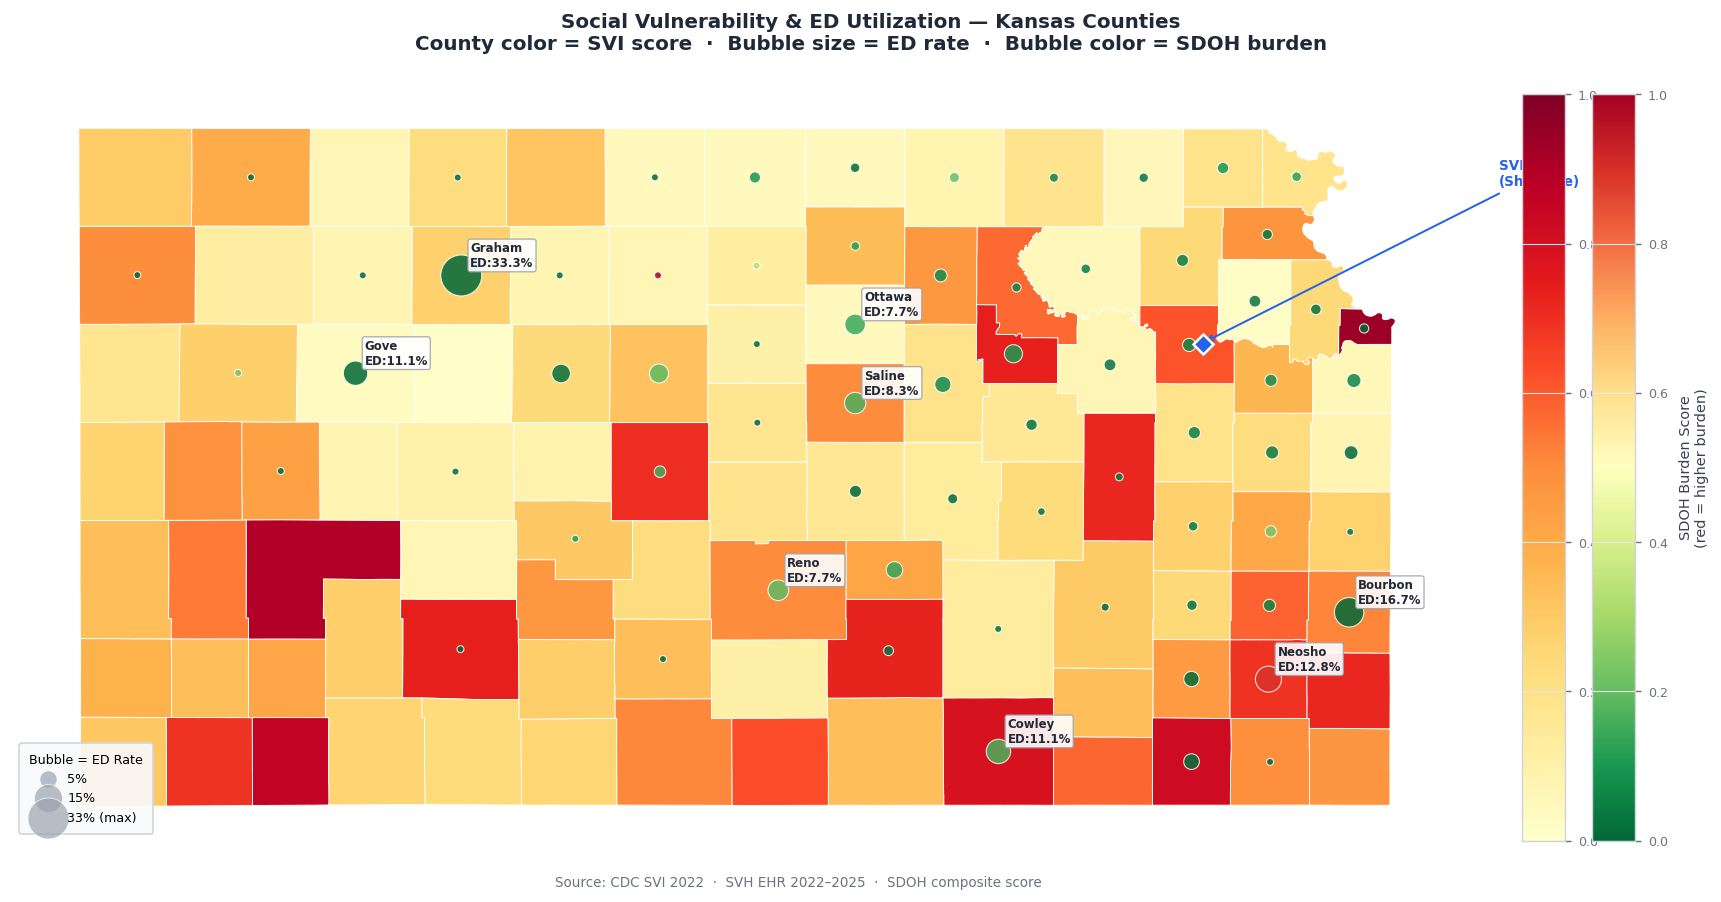

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot_svi_map.png


In [17]:
def plot_svi_map(sdoh_county, svi_ks):
    import geopandas as gpd
    import matplotlib.colors as mcolors
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    sc = sdoh_county.dropna(subset=['RPL_THEMES']).copy()

    # ── Shapefile ──────────────────────────────────────────────────────
    CACHE = f'{BASE}/ExternalData/ks_counties.gpkg'
    if os.path.exists(CACHE):
        ks_geo = gpd.read_file(CACHE)
    else:
        all_c  = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip')
        ks_geo = all_c[all_c['STATEFP'] == '20'].copy()
        ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
        ks_geo.to_file(CACHE, driver='GPKG')
    if 'FIPS' not in ks_geo.columns:
        ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']

    # ── Merge data ─────────────────────────────────────────────────────
    svi_slim = svi_ks[['FIPS','COUNTY','RPL_THEMES']].copy()
    svi_slim['FIPS'] = svi_slim['FIPS'].astype(str).str.zfill(5)
    ks_geo = ks_geo.merge(svi_slim, on='FIPS', how='left')

    sc['county_fips'] = sc['county_fips'].astype(str).str.zfill(5)
    ks_geo = ks_geo.merge(
        sc[['county_fips','county_label','ed_rate_pct','sdoh_mean','n_patients']],
        left_on='FIPS', right_on='county_fips', how='left'
    )
    ks_geo['cx'] = ks_geo.geometry.centroid.x
    ks_geo['cy'] = ks_geo.geometry.centroid.y

    # ── Figure: pakai GridSpec supaya kontrol penuh ────────────────────
    fig = plt.figure(figsize=(14, 7))
    fig.patch.set_facecolor('white')

    # ax utama peta, ax_svi colorbar kanan, ax_sdoh colorbar paling kanan
    import matplotlib.gridspec as gridspec
    gs  = gridspec.GridSpec(1, 3, width_ratios=[14, 0.4, 0.4],
                            left=0.01, right=0.92,
                            top=0.88, bottom=0.06,
                            wspace=0.05)
    ax      = fig.add_subplot(gs[0])
    ax_svi  = fig.add_subplot(gs[1])
    ax_sdoh = fig.add_subplot(gs[2])

    ax.set_facecolor('#EEF2F7')

    # ── Choropleth SVI ─────────────────────────────────────────────────
    norm_svi = mcolors.Normalize(vmin=0, vmax=1)
    cmap_svi = cm.get_cmap('YlOrRd')

    ks_geo.plot(
        column='RPL_THEMES', ax=ax,
        cmap='YlOrRd', linewidth=0.5, edgecolor='white',
        legend=False,
        missing_kwds={'color': '#D1D5DB'},
        vmin=0, vmax=1
    )

    # SVI colorbar manual di ax_svi
    cb1 = plt.colorbar(
        cm.ScalarMappable(norm=norm_svi, cmap='YlOrRd'),
        cax=ax_svi
    )
    cb1.set_label('SVI Score  (1 = most vulnerable)', fontsize=8, labelpad=6)
    cb1.ax.tick_params(labelsize=7)

    # ── Bubble: ukuran=ED rate, warna=SDOH burden ──────────────────────
    valid = ks_geo[
        ks_geo['ed_rate_pct'].notna() &
        ks_geo['sdoh_mean'].notna() &
        (ks_geo['n_patients'] > 0)
    ].copy()

    max_ed   = valid['ed_rate_pct'].max()
    max_sdoh = valid['sdoh_mean'].max()
    sizes    = (valid['ed_rate_pct'] / max_ed * 500 + 15)
    norm_b   = mcolors.Normalize(vmin=0, vmax=1)
    cmap_b   = cm.get_cmap('RdYlGn_r')
    c_vals   = valid['sdoh_mean'] / max_sdoh

    sc_plot = ax.scatter(
        valid['cx'], valid['cy'],
        s=sizes, c=c_vals,
        cmap='RdYlGn_r', norm=norm_b,
        alpha=0.85, edgecolors='white',
        linewidths=0.6, zorder=4
    )

    # SDOH colorbar di ax_sdoh
    cb2 = plt.colorbar(
        cm.ScalarMappable(norm=norm_b, cmap='RdYlGn_r'),
        cax=ax_sdoh
    )
    cb2.set_label('SDOH Burden Score\n(red = higher burden)', fontsize=8, labelpad=6)
    cb2.ax.tick_params(labelsize=7)

    # ── Label top 8 county ────────────────────────────────────────────
    top_labels = valid.nlargest(8, 'ed_rate_pct')
    for _, row in top_labels.iterrows():
        name = row.get('county_label', row.get('COUNTY', '?'))
        ax.annotate(
            f"{name}\nED:{row['ed_rate_pct']:.1f}%",
            xy=(row['cx'], row['cy']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=6.5, fontweight='bold', color='#1F2937',
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec='#9CA3AF', alpha=0.90, lw=0.7),
            zorder=5
        )

    # ── SVH marker ────────────────────────────────────────────────────
    ax.plot(-95.6752, 39.0473, 'D',
            ms=8, color='#2563EB', mec='white', mew=1.4, zorder=6)
    ax.annotate(
        'SVH\n(Shawnee)', xy=(-95.68, 39.05),
        xytext=(-94.0, 39.75),
        fontsize=7.5, color='#2563EB', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.1)
    )

    # ── Bubble size legend (pojok kiri bawah, di dalam peta) ──────────
    for ed_val, lbl in [(5, '5%'), (15, '15%'), (max_ed, f'{max_ed:.0f}% (max)')]:
        sz = ed_val / max_ed * 500 + 15
        ax.scatter([], [], s=sz, c='#9CA3AF', alpha=0.7,
                   edgecolors='white', lw=0.5, label=lbl)
    ax.legend(
        title='Bubble = ED Rate', title_fontsize=7,
        fontsize=7, loc='lower left',
        framealpha=0.92, edgecolor='#D1D5DB',
        borderpad=0.8, handletextpad=0.5
    )

    ax.set_axis_off()

    # ── Title ─────────────────────────────────────────────────────────
    fig.suptitle(
        'Social Vulnerability & ED Utilization — Kansas Counties\n'
        'County color = SVI score  ·  Bubble size = ED rate  ·  Bubble color = SDOH burden',
        fontsize=11, fontweight='bold', color='#1F2937', y=0.97
    )
    fig.text(
        0.46, 0.01,
        'Source: CDC SVI 2022  ·  SVH EHR 2022–2025  ·  SDOH composite score',
        ha='center', fontsize=7.5, color='#6B7280'
    )

    path = f'{OUTPUT_DIR}/plot_svi_map.png'
    plt.savefig(path, bbox_inches='tight', dpi=180)
    plt.show()
    print(f'✅ Saved: {path}')

plot_svi_map(sdoh_county, svi_ks)

---
## 16 · Plot 5 — County Intervention Need Score Map
> **Story:** Combining SVI, ED rate, transport burden, provider count, and HPSA designation into a single priority score per county.


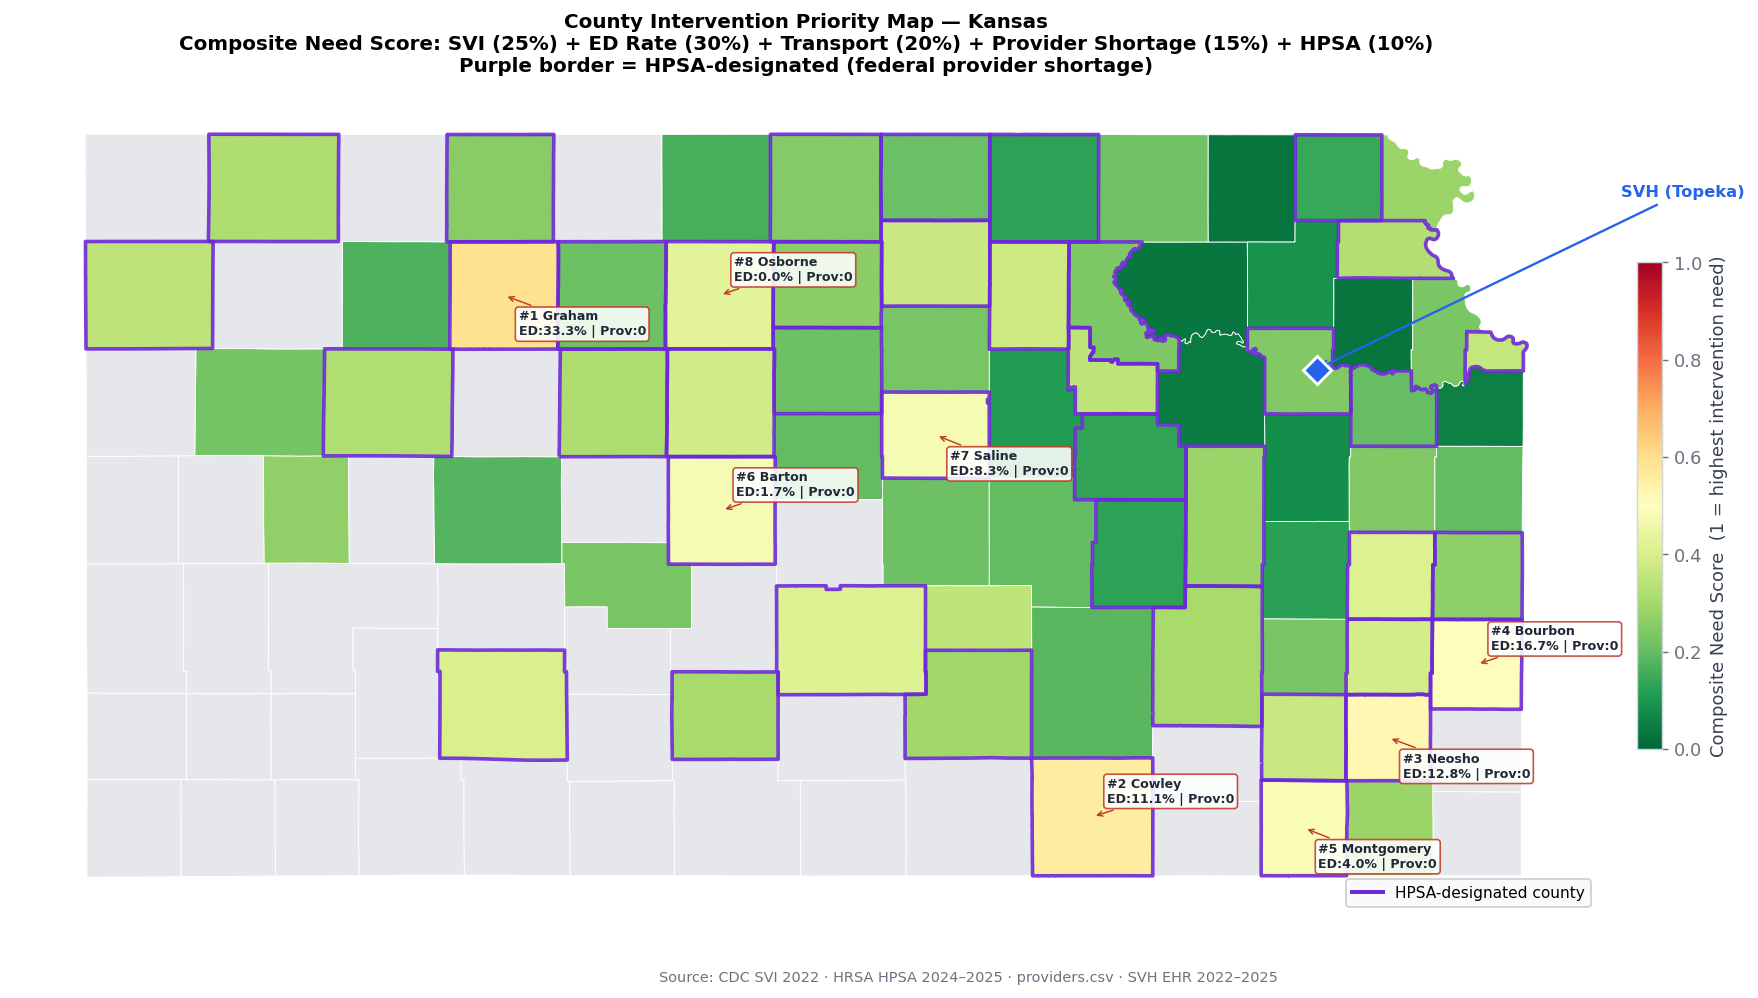


✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot5_need_score_map.png

Top 10 counties — priority intervention:
county_label  need_score  RPL_THEMES  ed_rate_pct  transport_pct  sdoh_mean  n_providers  hpsa_fte
      Graham      0.5918      0.2765      33.3333         0.0000     0.0000       0.0000    0.0800
      Cowley      0.5566      0.7871      11.1111        16.6667     0.5000       0.0000    2.0820
      Neosho      0.5252      0.6911      12.8440         3.6697     2.6789       0.0000    0.3460
     Bourbon      0.5047      0.5126      16.6667         0.0000     0.0000       0.0000    1.5900
  Montgomery      0.4840      0.8209       4.0359         0.8969     0.0538       0.0000    3.3730
      Barton      0.4764      0.7006       1.7241        18.9655     0.4655       0.0000    1.3970
      Saline      0.4759      0.5008       8.3281        20.1628     0.4934       0.0000    3.1710
     Osborne      0.4274      0.0687       0.0000       100.0000     3.0000    

In [18]:
def plot_need_score_map(sdoh_county):
    sc = sdoh_county.dropna(subset=['RPL_THEMES','need_score']).copy()

    try:
        import geopandas as gpd
        CACHE = f'{BASE}/ExternalData/ks_counties.gpkg'
        if os.path.exists(CACHE):
            ks_geo = gpd.read_file(CACHE)
        else:
            all_c  = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip')
            ks_geo = all_c[all_c['STATEFP'] == '20'].copy()
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
            ks_geo.to_file(CACHE, driver='GPKG')
        if 'FIPS' not in ks_geo.columns:
            ks_geo['FIPS'] = ks_geo['STATEFP'] + ks_geo['COUNTYFP']
        ks_geo = ks_geo.merge(sc, left_on='FIPS', right_on='county_fips', how='left')

        fig, ax = plt.subplots(figsize=(15, 7.5))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('#EEF2F7')

        ks_geo.plot(column='need_score', ax=ax, cmap='RdYlGn_r',
                    linewidth=0.5, edgecolor='white',
                    legend=True,
                    legend_kwds={'label':'Composite Need Score  (1 = highest intervention need)',
                                 'orientation':'vertical','shrink':0.55,'pad':0.02},
                    missing_kwds={'color':'#E5E7EB', 'label':'No patient data'},
                    vmin=0, vmax=1)

        # HPSA county border highlight
        hpsa_geo = ks_geo[ks_geo['is_hpsa'] == 1]
        if len(hpsa_geo) > 0:
            hpsa_geo.boundary.plot(ax=ax, color=C_HPSA, linewidth=2.0, zorder=3, alpha=0.9)

        # Label top 8 counties
        centroids = ks_geo.copy()
        centroids['cx'] = centroids.geometry.centroid.x
        centroids['cy'] = centroids.geometry.centroid.y
        top_need = centroids[centroids['need_score'].notna()].nlargest(8,'need_score')
        for rank, (_, row) in enumerate(top_need.iterrows(), 1):
            prov_int = int(row['n_providers']) if pd.notna(row['n_providers']) else 0
            ax.annotate(
                f"#{rank} {row.get('county_label','?')}\nED:{row['ed_rate_pct']:.1f}% | Prov:{prov_int}",
                xy=(row['cx'], row['cy']),
                xytext=(8, 8 if rank % 2 == 0 else -22), textcoords='offset points',
                fontsize=7, fontweight='bold', color='#1F2937',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#C0392B', alpha=0.88, lw=0.9),
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=0.8))

        ax.plot(-95.6752, 39.0473, 'D', ms=11, color=C_ACCENT, mec='white', mew=1.6, zorder=6)
        ax.annotate('SVH (Topeka)', xy=(-95.68,39.05), xytext=(-94.1,39.75),
                    fontsize=9, color=C_ACCENT, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.3))

        import matplotlib.lines as mlines
        hpsa_line = mlines.Line2D([],[],color=C_HPSA, linewidth=2.2, label='HPSA-designated county')
        ax.legend(handles=[hpsa_line], fontsize=8.5, loc='lower right', framealpha=0.9)
        ax.set_axis_off()
        ax.set_title(
            'County Intervention Priority Map — Kansas\n'
            'Composite Need Score: SVI (25%) + ED Rate (30%) + Transport (20%) + Provider Shortage (15%) + HPSA (10%)\n'
            'Purple border = HPSA-designated (federal provider shortage)',
            fontsize=11, fontweight='bold', pad=14)

    except Exception as e:
        print(f'⚠️  Choropleth failed ({e}) — bar fallback')
        fig, ax = plt.subplots(figsize=(12, 7))
        top_n   = sc.nlargest(25,'need_score').sort_values('need_score')
        colors_n = [C_RISK if v > 0.7 else C_WARN if v > 0.4 else C_SAFE for v in top_n['need_score']]
        bars = ax.barh(top_n['county_label'], top_n['need_score'], color=colors_n, edgecolor='white')
        for bar, (_, row) in zip(bars, top_n.iterrows()):
            ax.text(row['need_score']+0.005, bar.get_y()+bar.get_height()/2,
                    f"ED:{row['ed_rate_pct']:.1f}% | Prov:{int(row['n_providers'])} | SVI:{row['RPL_THEMES']:.2f}",
                    va='center', fontsize=7.5)
        ax.set_xlabel('Composite Need Score (0–1)', fontsize=10)
        ax.set_title('County Intervention Priority — Need Score Ranking', fontsize=12, fontweight='bold')

    fig.text(0.5, 0.005, 'Source: CDC SVI 2022 · HRSA HPSA 2024–2025 · providers.csv · SVH EHR 2022–2025',
             ha='center', fontsize=8, color=C_NEUTRAL)
    plt.tight_layout(rect=[0,0.02,1,1])
    path = f'{OUTPUT_DIR}/plot5_need_score_map.png'
    plt.savefig(path, bbox_inches='tight'); plt.show()
    print(f'\n✅ Saved: {path}')
    print('\nTop 10 counties — priority intervention:')
    cols_show = ['county_label','need_score','RPL_THEMES','ed_rate_pct',
                 'transport_pct','sdoh_mean','n_providers','hpsa_fte']
    print(sc.nlargest(10,'need_score')[cols_show].to_string(index=False))

plot_need_score_map(sdoh_county)


---
## 17 · Plot 6 — Supply Gap Heatmap: Top 20 Priority Counties
> **Final summary.** Each row = one county. Red = problem. Combines: SVI · SDOH Score · Transport % · ED Rate · Provider Count · HPSA FTE Shortage.


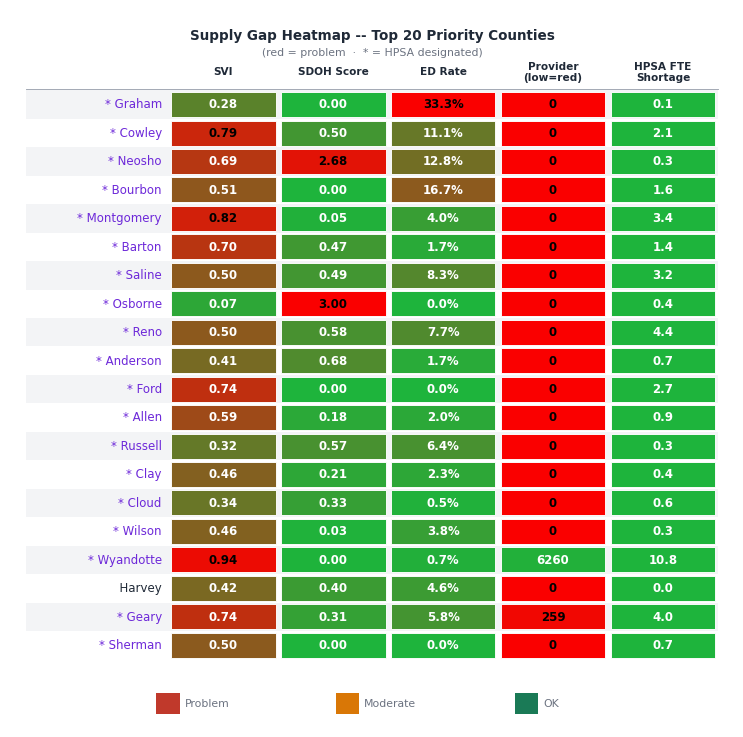

✅ Saved: /content/drive/MyDrive/ASAdatafest2026/outputs/last/plot6_supply_gap_heatmap.png


In [19]:
def plot_supply_gap_heatmap(sdoh_county):
    sc    = sdoh_county.dropna(subset=['RPL_THEMES', 'ed_rate_pct']).copy()
    top20 = sc.nlargest(20, 'need_score').reset_index(drop=True)

    def red_green(val):
        v = float(np.clip(val, 0, 1))
        r = int(min(255, 30  + v * 220))
        g = int(max(0,  180 - v * 180))
        b = int(max(0,   60 - v *  60))
        return f'#{r:02x}{g:02x}{b:02x}'

    def txt_col(hex_c):
        r = int(hex_c[1:3], 16)
        return '#000000' if r * 0.6 > 120 else '#FFFFFF'

    max_ed   = max(sc['ed_rate_pct'].max(), 1)
    max_prov = max(sc['n_providers'].max(), 1)
    max_sdoh = max(sc['sdoh_mean'].max() if 'sdoh_mean' in sc.columns else 1, 1)

    COLS = [
        ('SVI',
         lambda r: r['RPL_THEMES'],
         lambda r: f"{r['RPL_THEMES']:.2f}"),
        ('SDOH Score',
         lambda r: r.get('sdoh_mean', 0) / max_sdoh,
         lambda r: f"{r.get('sdoh_mean', 0):.2f}"),
        ('ED Rate',
         lambda r: r['ed_rate_pct'] / max_ed,
         lambda r: f"{r['ed_rate_pct']:.1f}%"),
        ('Provider\n(low=red)',
         lambda r: 1 - r['n_providers'] / max_prov,
         lambda r: str(int(r['n_providers']))),
        ('HPSA FTE\nShortage',
         lambda r: 0.0,
         lambda r: f"{r.get('hpsa_fte', 0):.1f}"),
    ]

    # ── Dimensi ultra compact ─────────────────────────────────────────
    n_rows = len(top20)
    n_cols = len(COLS)
    ch     = 0.22    # row height
    cw     = 0.85    # cell width
    name_w = 1.10    # county name width
    pad_l  = 0.10
    pad_r  = 0.10

    fig_w = pad_l + name_w + n_cols * cw + pad_r
    fig_h = n_rows * ch + 1.10

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_axis_off()
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, fig_h)

    x0       = pad_l + name_w
    title_y  = fig_h - 0.12
    header_y = fig_h - 0.46

    # ── Title ─────────────────────────────────────────────────────────
    ax.text(fig_w / 2, title_y,
            'Supply Gap Heatmap -- Top 20 Priority Counties',
            ha='center', va='top',
            fontsize=7.5, fontweight='bold', color=C_DARK)
    ax.text(fig_w / 2, title_y - 0.15,
            '(red = problem  ·  * = HPSA designated)',
            ha='center', va='top',
            fontsize=6, color=C_NEUTRAL)

    # ── Header ────────────────────────────────────────────────────────
    for j, (col_name, _, _) in enumerate(COLS):
        ax.text(x0 + j * cw + cw / 2, header_y,
                col_name,
                ha='center', va='center',
                fontsize=5.8, fontweight='bold', color=C_DARK,
                linespacing=1.1)

    ax.plot([pad_l, fig_w - pad_r],
            [header_y - 0.13, header_y - 0.13],
            color='#9CA3AF', linewidth=0.5)

    # ── Rows ──────────────────────────────────────────────────────────
    row_start_y = header_y - 0.13 - ch * 0.55

    for i, (_, row) in enumerate(top20.iterrows()):
        y  = row_start_y - i * ch
        bg = '#F3F4F6' if i % 2 == 0 else '#FFFFFF'

        ax.add_patch(plt.Rectangle(
            (pad_l, y - ch * 0.50), fig_w - pad_l - pad_r, ch,
            facecolor=bg, edgecolor='none', zorder=0
        ))

        # County name
        is_hpsa = int(row.get('is_hpsa', 0)) == 1
        star    = '* ' if is_hpsa else '  '
        ax.text(x0 - 0.05, y,
                f'{star}{row.get("county_label", "?")}',
                ha='right', va='center',
                fontsize=6.5,
                color=C_HPSA if is_hpsa else C_DARK)

        # Cells
        for j, (_, norm_fn, disp_fn) in enumerate(COLS):
            norm_val = float(np.clip(norm_fn(row), 0, 1))
            display  = disp_fn(row)
            cell_c   = red_green(norm_val)
            cx       = x0 + j * cw

            ax.add_patch(plt.Rectangle(
                (cx + 0.02, y - ch * 0.44), cw - 0.04, ch * 0.88,
                facecolor=cell_c, edgecolor='white',
                linewidth=0.5, zorder=1
            ))
            ax.text(cx + cw / 2, y, display,
                    ha='center', va='center',
                    fontsize=6.5, color=txt_col(cell_c),
                    fontweight='bold', zorder=2)

    # ── Legend ────────────────────────────────────────────────────────
    leg_y   = 0.16
    spacing = fig_w / 4
    for k, (lbl, clr) in enumerate([
        ('Problem',  C_RISK),
        ('Moderate', C_WARN),
        ('OK',       C_SAFE),
    ]):
        lx = spacing * (k + 1) - 0.28
        ax.add_patch(plt.Rectangle(
            (lx, leg_y - 0.08), 0.18, 0.16,
            facecolor=clr, edgecolor='none'
        ))
        ax.text(lx + 0.22, leg_y, lbl,
                va='center', fontsize=6, color=C_NEUTRAL)

    plt.tight_layout(pad=0.1)
    path = f'{OUTPUT_DIR}/plot6_supply_gap_heatmap.png'
    plt.savefig(path, bbox_inches='tight', dpi=180)
    plt.show()
    print(f'✅ Saved: {path}')

plot_supply_gap_heatmap(sdoh_county)

---
## 18 · Output Summary

In [20]:
import glob as _glob

print('='*65)
print('  TRAPPED AT THE WRONG DOOR — OUTPUT SUMMARY')
print('='*65)

files = sorted(_glob.glob(f'{OUTPUT_DIR}/*.png'))
if files:
    for f in files:
        print(f'  {os.path.basename(f):<55} {os.path.getsize(f)//1024:>4} KB')
    print(f'\n  Total: {len(files)} figures saved to {OUTPUT_DIR}')
else:
    print('  No PNG files found — check OUTPUT_DIR path')

print()
print('Key headline numbers:')
t_ed  = master_df[master_df['Transport_Issue']==1]['IsEdVisit'].mean()*100
nt_ed = master_df[master_df['Transport_Issue']==0]['IsEdVisit'].mean()*100
hb_ed = master_df[master_df['burden_tier']=='High Burden (3+)']['IsEdVisit'].mean()*100
nb_ed = master_df[master_df['burden_tier']=='No Burden']['IsEdVisit'].mean()*100
n_hp  = master_df[master_df['is_hpsa_designated']==1]['PatientDurableKey'].nunique()

print(f'  ED rate — transport burdened  : {t_ed:.2f}%')
print(f'  ED rate — no transport burden : {nt_ed:.2f}%  (ratio: {t_ed/nt_ed:.1f}x)')
print(f'  ED rate — high SDOH burden    : {hb_ed:.2f}%')
print(f'  ED rate — no SDOH burden      : {nb_ed:.2f}%  (ratio: {hb_ed/nb_ed:.1f}x)')
print(f'  Patients in HPSA counties     : {n_hp:,}')
print('='*65)
print('\n✅ Notebook complete! All figures saved.')


  TRAPPED AT THE WRONG DOOR — OUTPUT SUMMARY
  plot1_sdoh_burden_ed.png                                 143 KB
  plot2_ed_cycling.png                                      87 KB
  plot3_sdoh_correlation.png                               261 KB
  plot4_hpsa_transport.png                                 412 KB
  plot5_need_score_map.png                                 312 KB
  plot6_supply_gap_heatmap.png                             137 KB
  plot_svi_map.png                                         252 KB

  Total: 7 figures saved to /content/drive/MyDrive/ASAdatafest2026/outputs/last

Key headline numbers:
  ED rate — transport burdened  : 6.64%
  ED rate — no transport burden : 2.33%  (ratio: 2.8x)
  ED rate — high SDOH burden    : 13.29%
  ED rate — no SDOH burden      : 2.19%  (ratio: 6.1x)
  Patients in HPSA counties     : 40,167

✅ Notebook complete! All figures saved.
